<h2>Importing Libraries</h2>

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import calendar
import pickle
import scipy.stats as stats
import optuna
import matplotlib.pyplot as plt
%matplotlib inline
import datetime
from sklearn import preprocessing
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import category_encoders as ce
from sklearn.ensemble import ExtraTreesClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score,f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

<h2>Read Dataset</h2>

In [2]:
data_set=pd.read_csv(r"C:\Users\donku\OneDrive\Desktop\group-d-hotel-booking-mgmt-system\AIML\generated.csv")
property_set=pd.read_csv(r"C:\Users\donku\Downloads\Hotel_Booking_Mgmt\dim_hotels.csv")
data_set.head()

,Unnamed: 0,booking_date,no_guests,room_category,booking_status,check_in_date,checkout_date,property_id,booking_id,booking_platform,ratings_given,revenue_generated,revenue_realized
0,0,2022-05-16,4,RT2,No Show,2022-05-23,2022-05-28,18561,NaN,NaN,NaN,NaN,NaN
1,1,2022-06-14,4,RT4,Cancelled,2022-06-16,2022-06-20,17558,NaN,NaN,NaN,NaN,NaN
2,2,2022-07-15,2,RT3,No Show,2022-07-18,2022-07-23,18560,NaN,NaN,NaN,NaN,NaN
3,3,2022-05-31,4,RT3,Cancelled,2022-06-04,2022-06-06,16562,NaN,NaN,NaN,NaN,NaN
4,4,2022-06-30,3,RT2,Cancelled,2022-07-05,2022-07-07,16559,NaN,NaN,NaN,NaN,NaN


In [3]:
property_set.head()

,property_id,property_name,category,city
0,16558,Atliq Grands,Luxury,Delhi
1,16559,Atliq Exotica,Luxury,Delhi
2,16560,Atliq City,Business,Delhi
3,16561,Atliq Blu,Luxury,Delhi
4,16562,Atliq Bay,Luxury,Delhi


In [4]:
hotel_category=[['Atliq Grands','Delhi','Luxury'],['Atliq Exotica','Delhi','Luxury'],['Atliq City','Delhi','Business'],['Atliq Blu','Delhi','Luxury'],['Atliq Bay','Delhi','Luxury'],['Atliq Palace','Delhi','Business'],['Atliq Grands','Mumbai','Luxury'],['Atliq Exotica','Mumbai','Luxury'],['Atliq City','Mumbai','Business'],['Atliq Blu','Mumbai','Luxury'],['Atliq Bay','Mumbai','Luxury'],['Atliq Palace','Mumbai','Business'],['Atliq Grands','Hyderabad','Luxury'],['Atliq Exotica','Hyderabad','Luxury'],['Atliq City','Hyderabad','Business'],['Atliq Blu','Hyderabad','Luxury'],['Atliq Bay','Hyderabad','Luxury'],['Atliq Palace','Hyderabad','Business'],['Atliq Grands','Bangalore','Luxury'],['Atliq Exotica','Bangalore','Luxury'],['Atliq City','Bangalore','Business'],['Atliq Blu','Bangalore','Luxury'],['Atliq Bay','Bangalore','Luxury'],['Atliq Palace','Bangalore','Business'],['Atliq Seasons','Mumbai','Business']]

<h2>Dataset Basic Information</h2>

In [5]:
data_set=pd.merge(data_set,property_set,on='property_id',how='left')

In [6]:
data_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182300 entries, 0 to 182299
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         182300 non-null  int64  
 1   booking_date       182300 non-null  object 
 2   no_guests          182300 non-null  int64  
 3   room_category      182300 non-null  object 
 4   booking_status     182300 non-null  object 
 5   check_in_date      182300 non-null  object 
 6   checkout_date      182300 non-null  object 
 7   property_id        182300 non-null  int64  
 8   booking_id         134590 non-null  object 
 9   booking_platform   134590 non-null  object 
 10  ratings_given      56683 non-null   float64
 11  revenue_generated  134590 non-null  float64
 12  revenue_realized   134590 non-null  float64
 13  property_name      182300 non-null  object 
 14  category           182300 non-null  object 
 15  city               182300 non-null  object 
dtypes:

In [7]:
data_set.shape

(182300, 16)

<h2>Statistics Information</h2>

In [8]:
data_set.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,182300.0,55925.753977,39099.065656,0.0,22787.0,45574.5,89014.25,134589.0
no_guests,182300.0,2.419281,1.398477,1.0,1.0,2.0,3.00,6.0
property_id,182300.0,18054.625041,1094.431881,16558.0,17558.0,17564.0,18563.00,19563.0
ratings_given,56683.0,3.619004,1.235009,1.0,3.0,4.0,5.00,5.0
revenue_generated,134590.0,14916.013188,6452.868072,6500.0,9900.0,13500.0,18000.00,45220.0
revenue_realized,134590.0,12696.123256,6928.108124,2600.0,7600.0,11700.0,15300.00,45220.0


In [9]:
data_set.describe(include="object").T

,count,unique,top,freq
booking_date,182300,116,2022-06-08,2198
room_category,182300,4,RT2,61415
booking_status,182300,3,Checked Out,94411
check_in_date,182300,102,2022-07-16,2547
checkout_date,182300,107,2022-07-04,2337
booking_id,134590,134590,May012216558RT11,1
booking_platform,134590,7,others,55066
property_name,182300,7,Atliq Palace,31278
category,182300,2,Luxury,114203
city,182300,4,Mumbai,49375


<h2>Removal of Duplicates and Dropping of Unwanted Data</h2>

In [10]:
data_set.isnull().sum()

Unnamed: 0                0
booking_date              0
no_guests                 0
room_category             0
booking_status            0
check_in_date             0
checkout_date             0
property_id               0
booking_id            47710
booking_platform      47710
ratings_given        125617
revenue_generated     47710
revenue_realized      47710
property_name             0
category                  0
city                      0
dtype: int64

In [11]:
data_set.duplicated().sum()

0

In [12]:
#Removal Of Unwanted Data
#booking_id is removed due to the unique values alloted for each booking. This doesn't help the model to generalize patterns.
#ratings_given and revenue_realized are removed as it is received at the end of the transaction (Post-Event Information).
data_set=data_set.drop(columns=['Unnamed: 0','booking_id','ratings_given','revenue_realized','category'])

<h2>Explanatory Data Analysis and Preprocessing</h2>

In [13]:
data_set.columns

Index(['booking_date', 'no_guests', 'room_category', 'booking_status',
       'check_in_date', 'checkout_date', 'property_id', 'booking_platform',
       'revenue_generated', 'property_name', 'city'],
      dtype='object')

<h2>Values in Categorical values</h2>

In [14]:
data_set=data_set.assign(no_days_book_to_checkin=None,no_days_checkin_checkout=None,rev_person=None,booking_month=None,check_month=None,no_weekend=None,booking_day=None,check_in_day=None,check_out_day=None,category=None)

In [15]:
#Finding the number of days between booking_date and check_in_date
def no_of_days_between(from_date,to_date,weekend):
    booking_checkin=[]
    for c in range (len(data_set)):
        holiday=0
        f_date=datetime.datetime.strptime(data_set[from_date][c], '%Y-%m-%d').date()
        t_date=datetime.datetime.strptime(data_set[to_date][c], '%Y-%m-%d').date()
        no_days=t_date-f_date
        booking_checkin.append(no_days.days)
        delta=datetime.timedelta(days=1)
        if weekend==True:
            for i in range(len(hotel_category)):
                if (hotel_category[i][0]==data_set["property_name"][c]) and (hotel_category[i][1]==data_set["city"][c]):
                    data_set.loc[c,"category"]=hotel_category[i][2]
            while (f_date<=t_date):
                f_date+=delta
                if(f_date.weekday()>=5):
                    holiday+=1
            no_week.append(holiday)
    return(booking_checkin)

In [16]:
categorical_data=['property_id','room_category','booking_platform','booking_status','property_name','category','city']

In [17]:
for i in categorical_data:
    data_set[i]=data_set[i].astype("object")

In [18]:
data_set.tail()

,booking_date,no_guests,room_category,booking_status,check_in_date,checkout_date,property_id,booking_platform,revenue_generated,property_name,...,no_days_book_to_checkin,no_days_checkin_checkout,rev_person,booking_month,check_month,no_weekend,booking_day,check_in_day,check_out_day,category
182295,2022-07-29,1,RT4,Checked Out,2022-07-31,2022-08-03,17564,makeyourtrip,32300.0,Atliq Seasons,...,None,None,None,None,None,None,None,None,None,None
182296,2022-07-30,4,RT4,Checked Out,2022-07-31,2022-08-01,17564,logtrip,38760.0,Atliq Seasons,...,None,None,None,None,None,None,None,None,None,None
182297,2022-07-30,1,RT4,Cancelled,2022-07-31,2022-08-02,17564,tripster,32300.0,Atliq Seasons,...,None,None,None,None,None,None,None,None,None,None
182298,2022-07-29,2,RT4,Checked Out,2022-07-31,2022-08-01,17564,logtrip,32300.0,Atliq Seasons,...,None,None,None,None,None,None,None,None,None,None
182299,2022-07-31,2,RT4,Cancelled,2022-07-31,2022-08-01,17564,makeyourtrip,32300.0,Atliq Seasons,...,None,None,None,None,None,None,None,None,None,None


<h3> Feature Engineering </h3>
<h5> New Feature: rev_person is the revenue_generated per no_guests </h6>
<h5> New Feature: no_days_book_to_checkin is the number of the days between booking date and check in date </h6>
<h5> New Feature: no_days_checkin_checkout is the number of the days between check in date and checkout date </h6>
<h5> New Feature: book_month is the month of the booking date </h6>
<h5> New Feature: check_month is the month of check in and checkout date </h6>

In [19]:
no_week=[]
data_set["no_days_book_to_checkin"]=no_of_days_between('booking_date','check_in_date',weekend=False)
data_set["no_days_checkin_checkout"]=no_of_days_between('check_in_date','checkout_date',weekend=True)
data_set["no_weekend"]=no_week
data_set["booking_day"]=data_set['booking_date'].apply(lambda x:x.split("-")[2]).astype(int)
data_set["check_in_day"]=data_set['check_in_date'].apply(lambda x:x.split("-")[2]).astype(int)
data_set["check_out_day"]=data_set['checkout_date'].apply(lambda x:x.split("-")[2]).astype(int)
data_set["booking_month"]=data_set['booking_date'].apply(lambda x:x.split("-")[1]).astype(int)
data_set["check_month"]=(data_set['check_in_date'].apply(lambda x:x.split("-")[1]).astype(int)+data_set['checkout_date'].apply(lambda x:x.split("-")[1]).astype(int))/2

In [20]:
for column in categorical_data:
    print(data_set[column].value_counts().sort_values(ascending=False))
    print('\n')

property_id
16559    9294
18562    9225
16563    9040
18560    8511
18561    8440
17563    8240
17559    7972
17560    7950
19560    7864
19561    7662
19562    7627
19563    7295
18559    7242
17561    7061
17558    6921
18563    6703
16562    6646
16560    6617
19559    6616
18558    6401
16561    6396
19558    6245
17564    5877
17562    5354
16558    5101
Name: count, dtype: int64


room_category
RT2    61415
RT1    50477
RT3    42450
RT4    27958
Name: count, dtype: int64


booking_platform
others            55066
makeyourtrip      26898
logtrip           14756
direct online     13379
tripster           9630
journey            8106
direct offline     6755
Name: count, dtype: int64


booking_status
Checked Out    94411
Cancelled      57259
No Show        30630
Name: count, dtype: int64


property_name
Atliq Palace     31278
Atliq Exotica    31124
Atliq City       30942
Atliq Blu        29559
Atliq Bay        28852
Atliq Grands     24668
Atliq Seasons     5877
Name: count, dtype: in

<h1> Outlier Detection and Removal</h1>

<Axes: ylabel='revenue_generated'>

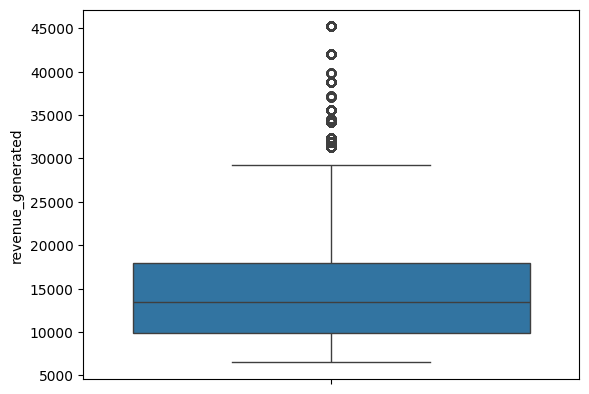

In [21]:
sns.boxplot(data_set['revenue_generated'])

<Axes: ylabel='no_days_book_to_checkin'>

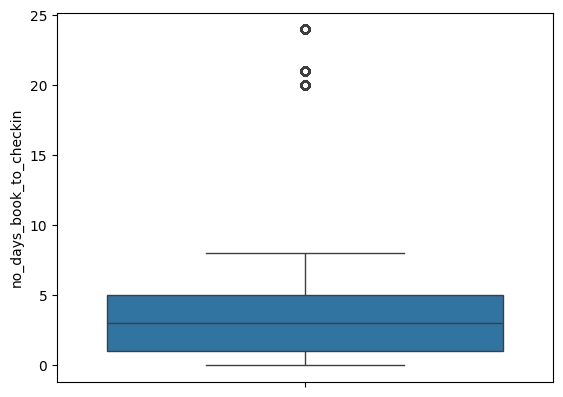

In [22]:
sns.boxplot(data_set['no_days_book_to_checkin'])

In [23]:
def iqr_method(outlier):
    #Removing Outliers using IQR Method
    q1=data_set[outlier].quantile(0.25)
    q3=data_set[outlier].quantile(0.75)
    iqr=q3-q1
    upper_limit = q3 + (1.5*iqr)
    lower_limit = q1 - (1.5*iqr)
    #capping
    data_set.loc[(data_set[outlier]>upper_limit),outlier]=upper_limit
    data_set.loc[(data_set[outlier]<lower_limit),outlier]=lower_limit

In [24]:
iqr_method('revenue_generated')
iqr_method('no_days_book_to_checkin')

<Axes: ylabel='no_days_book_to_checkin'>

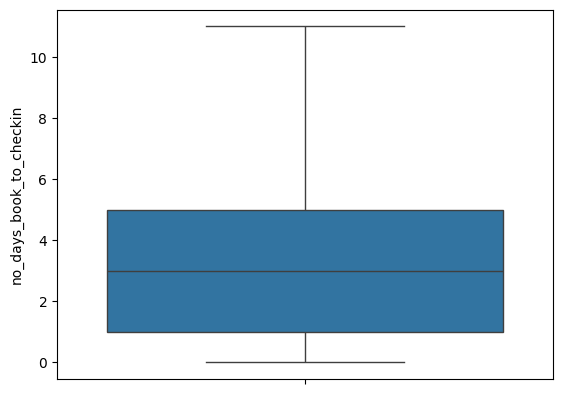

In [25]:
sns.boxplot(data_set['no_days_book_to_checkin'])

<Axes: ylabel='revenue_generated'>

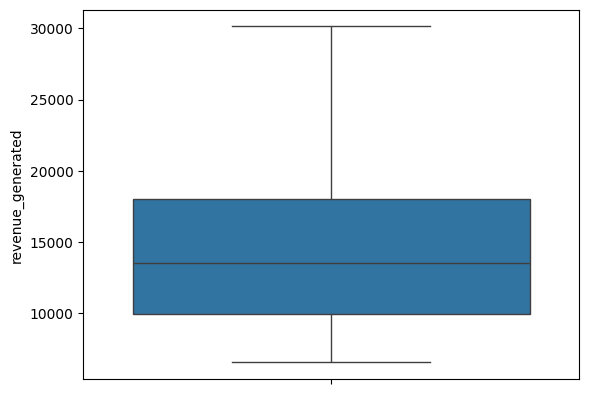

In [26]:
sns.boxplot(data_set['revenue_generated'])

In [27]:
data_set["rev_person"]=data_set["revenue_generated"]/data_set["no_guests"]

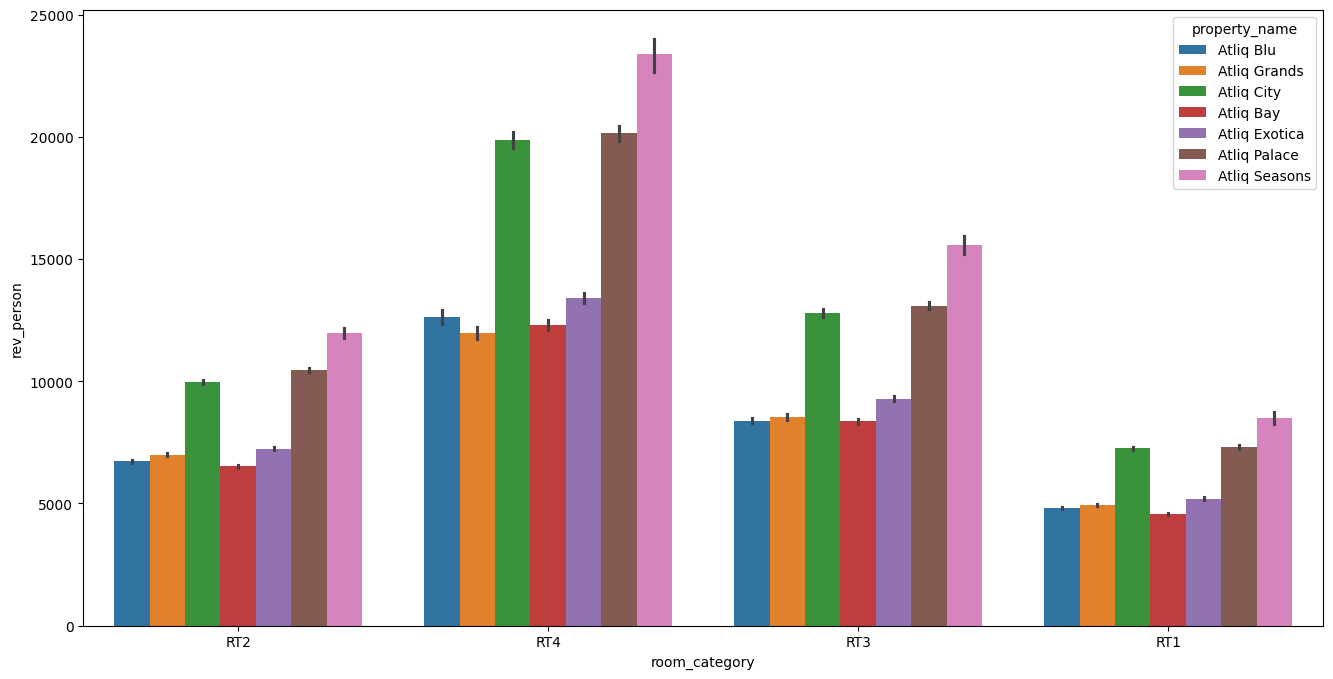

In [28]:
plt.figure(figsize=(16,8))
sns.barplot(data=data_set, x="room_category",y="rev_person",hue="property_name")
plt.show()

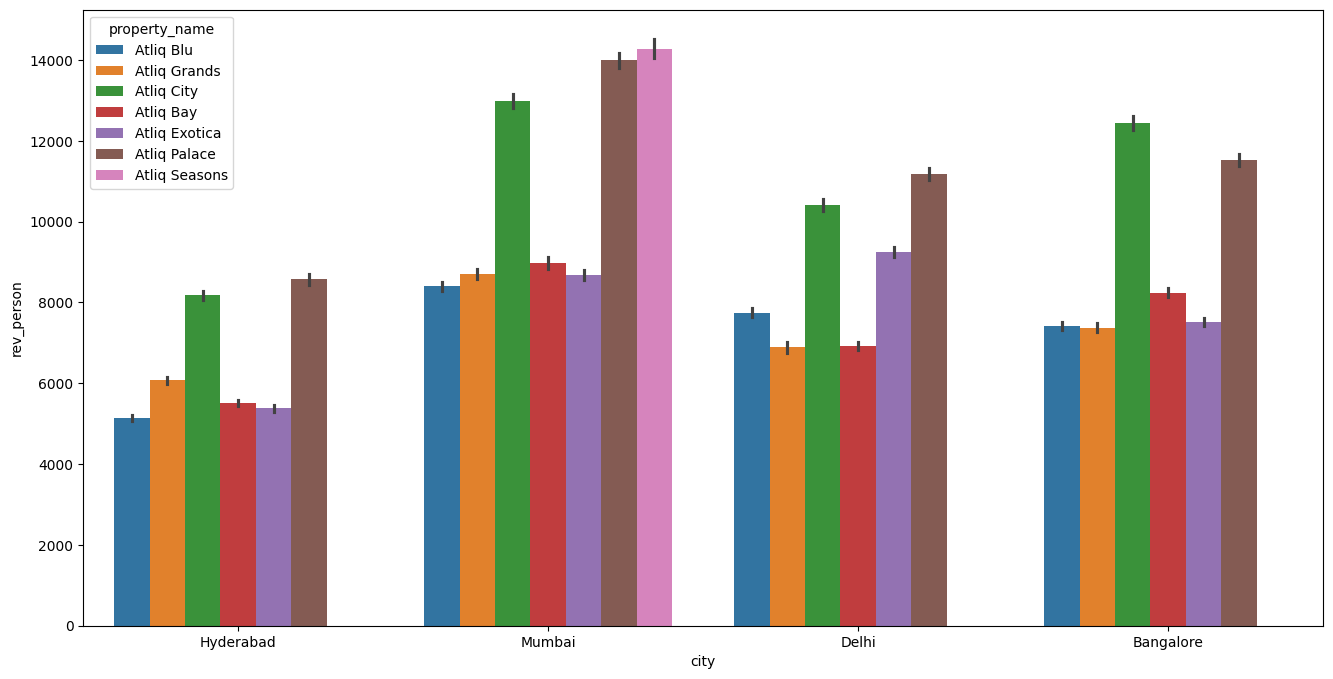

In [29]:
plt.figure(figsize=(16,8))
sns.barplot(data=data_set, x="city",y="rev_person",hue="property_name")
plt.show()

In [30]:
#Removal of Data which is done after feature generation
data_set=data_set.drop(columns=['booking_date','check_in_date','checkout_date'],axis=0)

<h5> Behaviour of booking_status based on input variables </h5>
<h5> Out of 134590 reservation, Checked Out - 94411, Cancelled -  33420 , No Show - 6579</h5>
<h5> The output variable is considered on the basis of room cancellation,</h5>
<h5> So a new columns has been created 'is_cancelled' which considers Cancelled and No Show as 1 while the Checked Out as 0  </h5>
<h5> Out of the seven hotels, Atliq Season charges more for their rooms compared to others. </h5>
<h5> Most reservation are booked for two guests and the room category (RT2) </h5>
<h5> Most of the reservation are reserved through other means </h5>
<h5> Luxury type hotels are reserved more than the Business ones </h5>
<h5> Most people reserve their rooms for one day and book them within three days before the check-in date </h5>

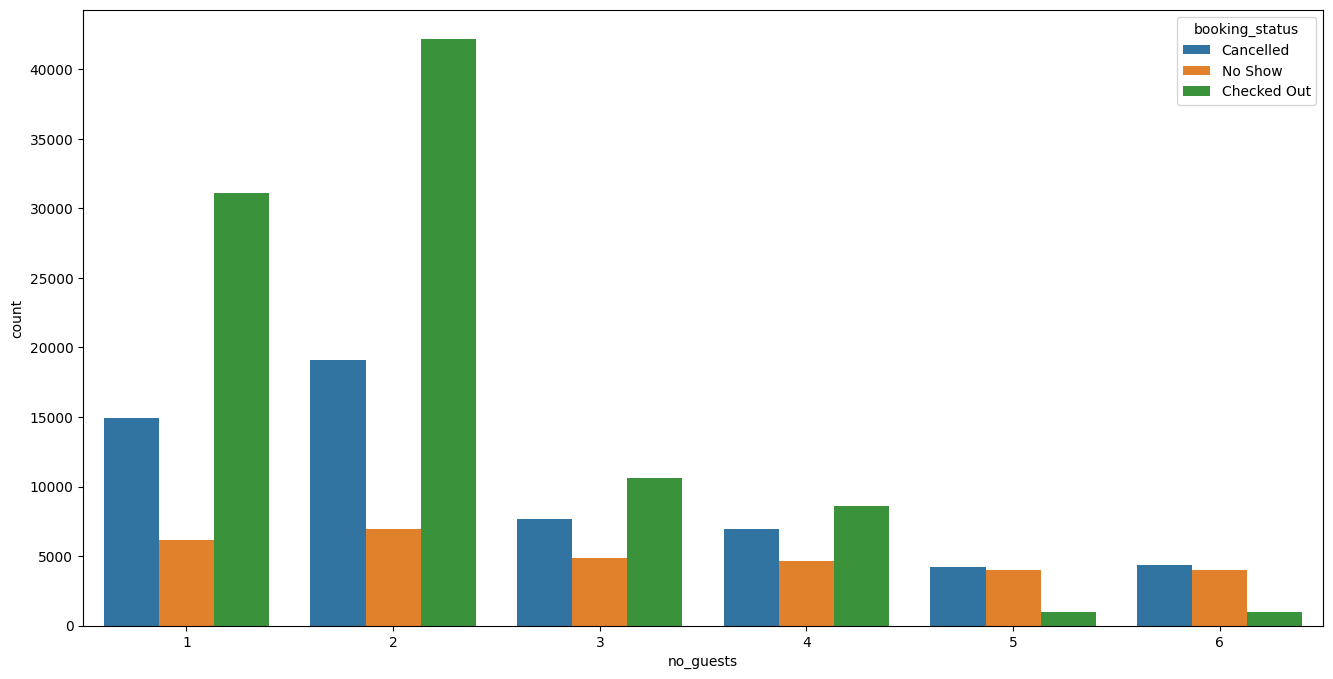

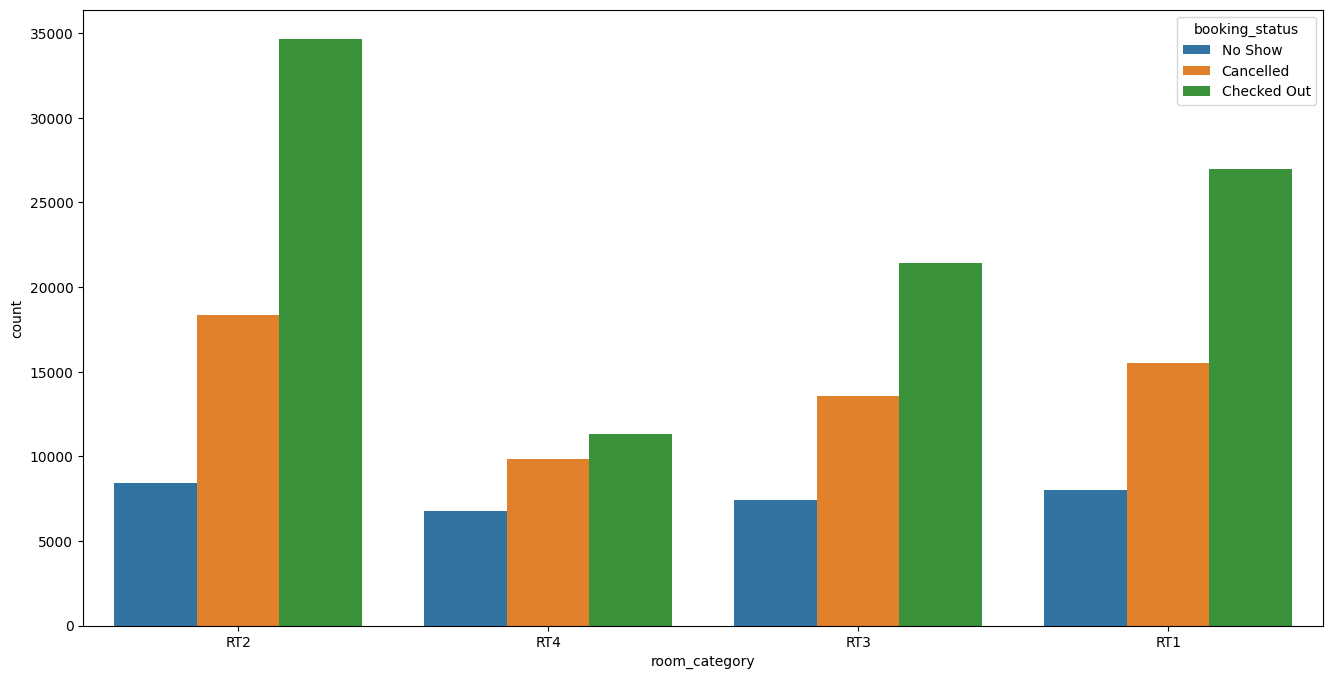

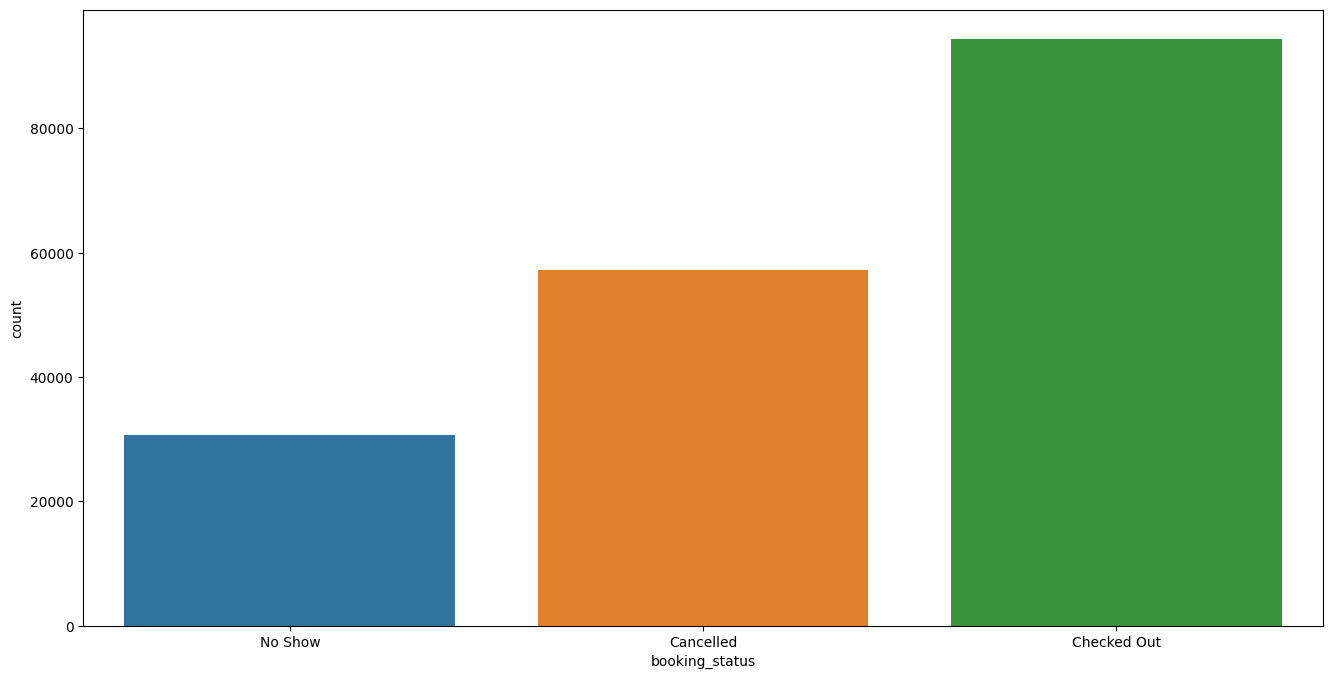

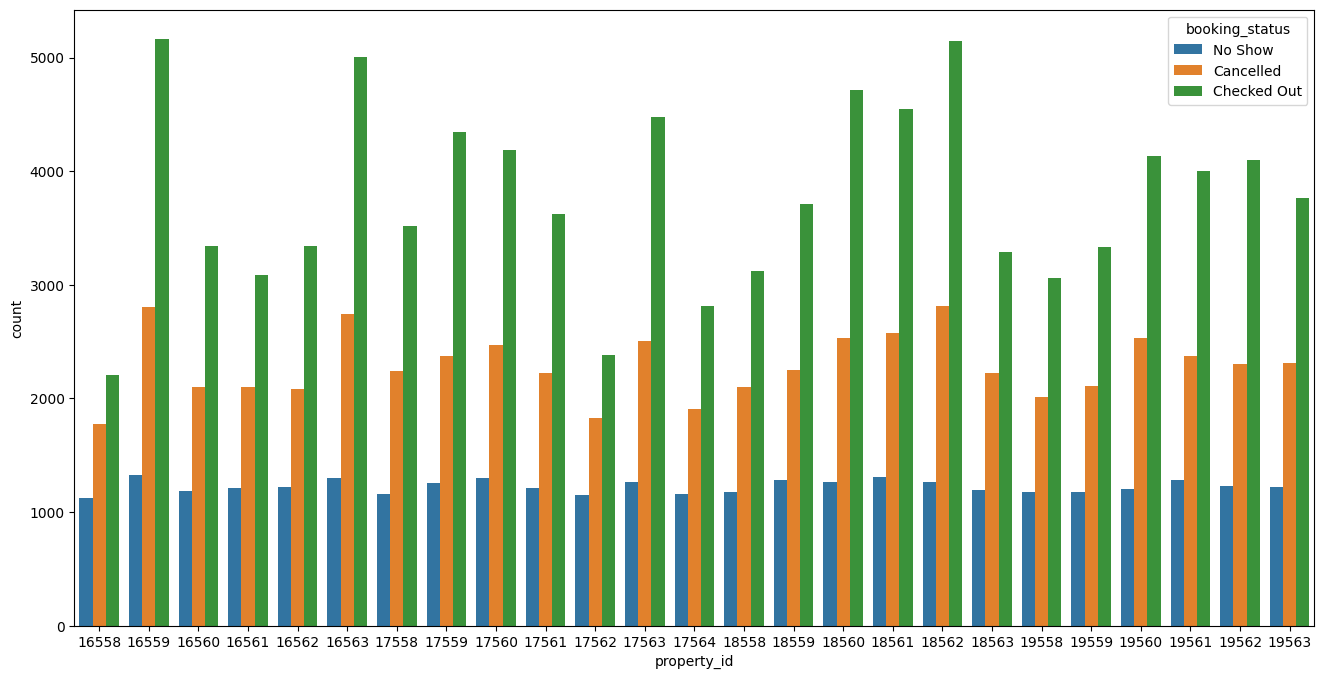

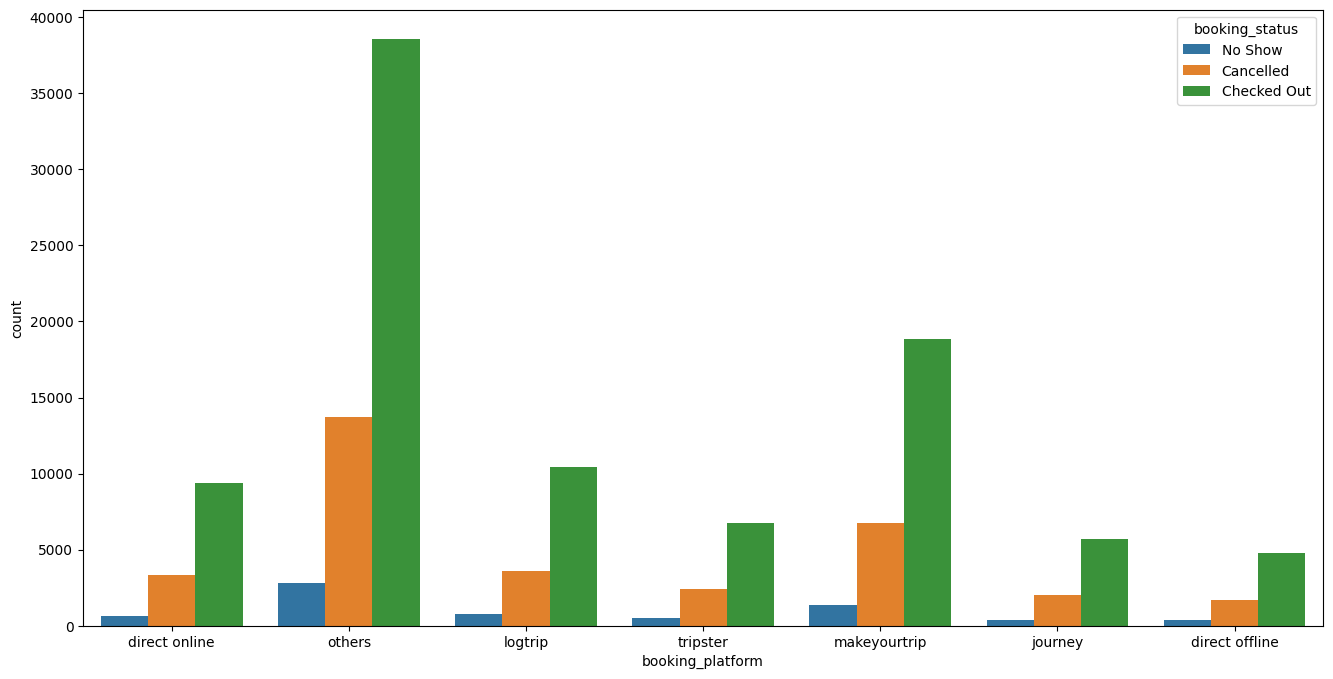

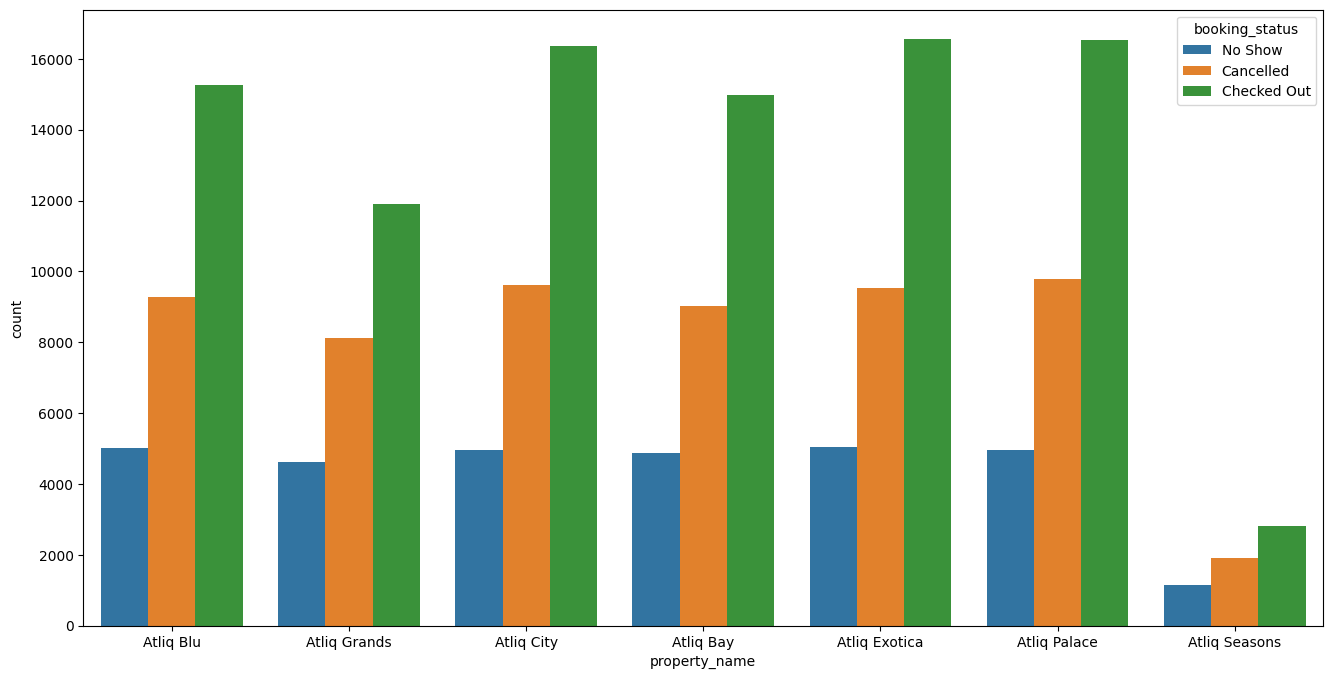

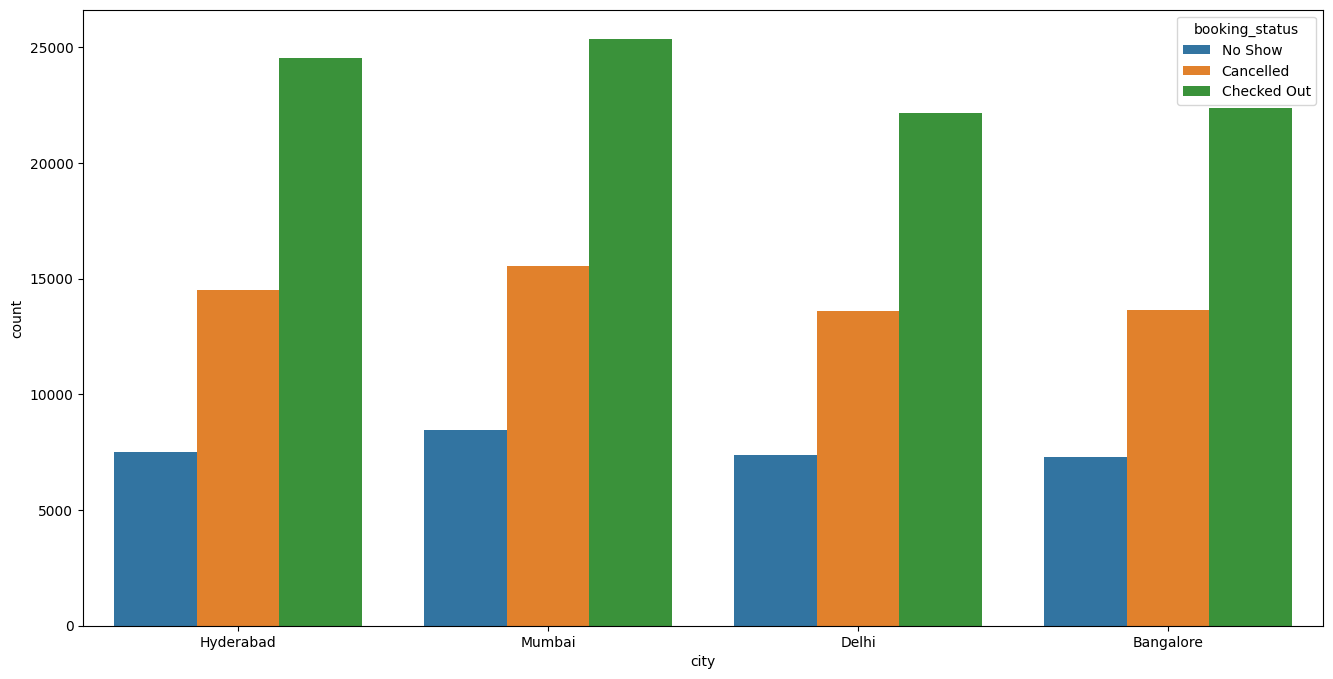

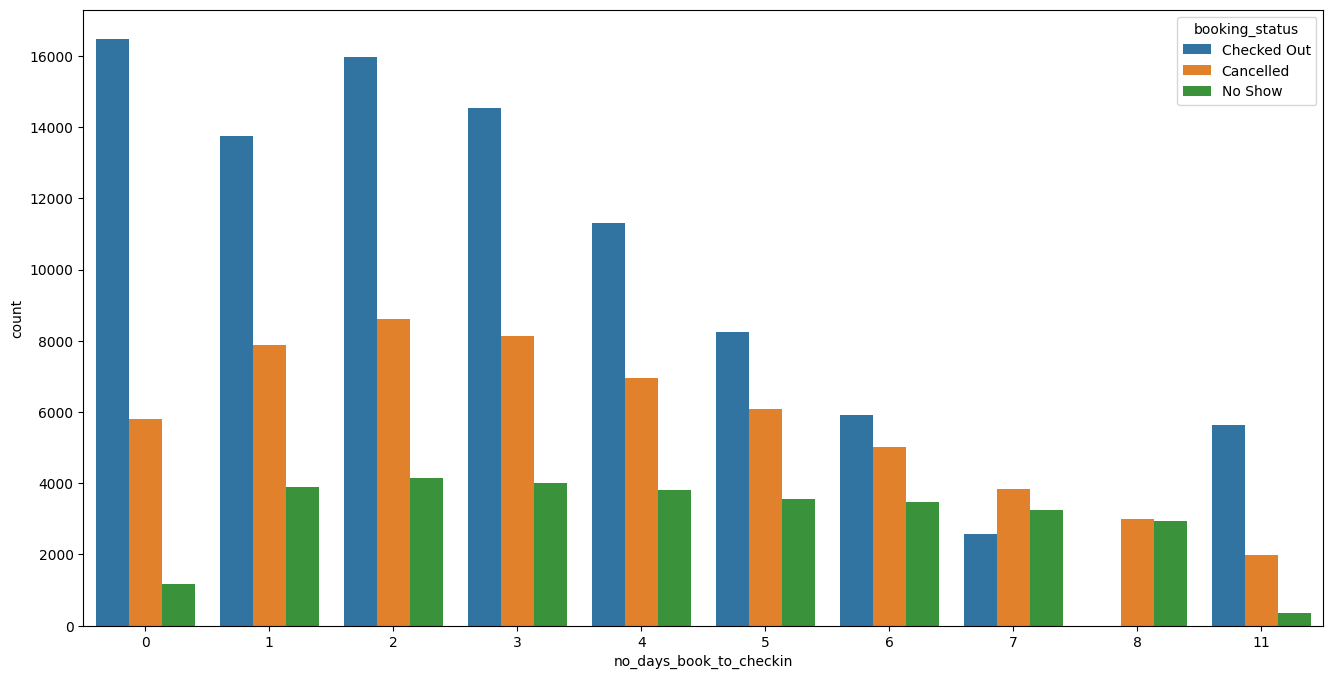

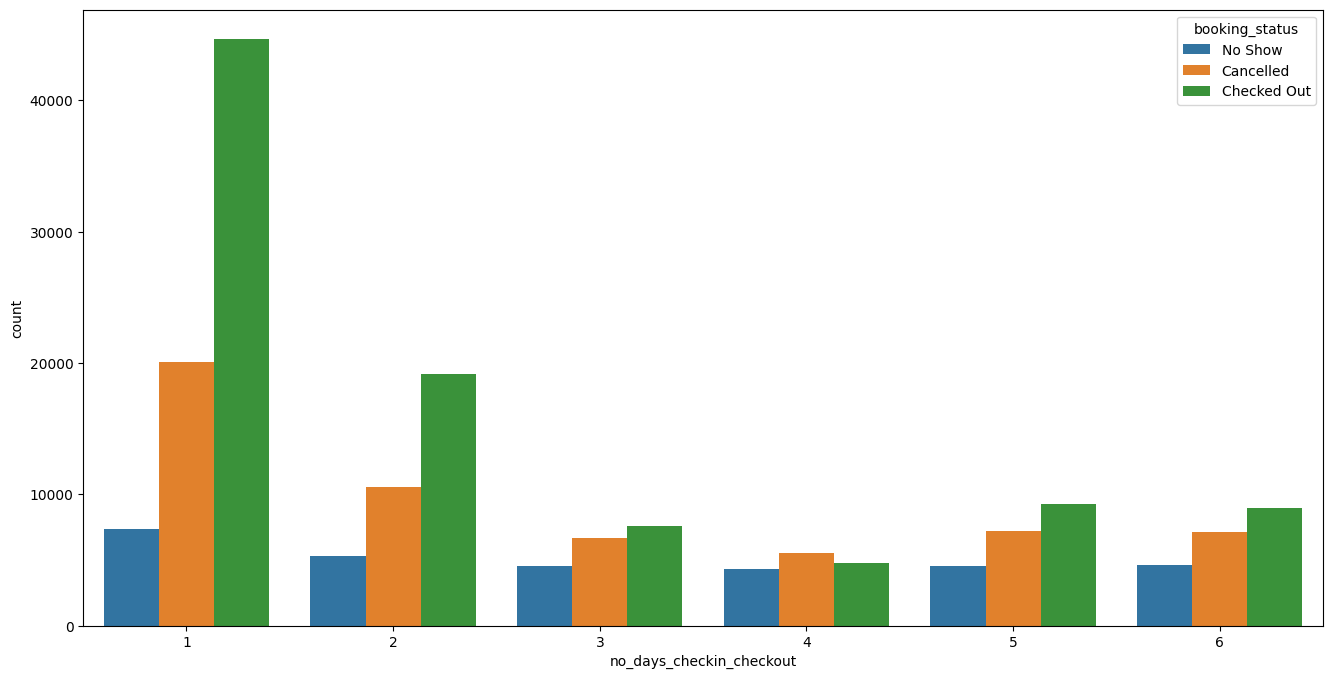

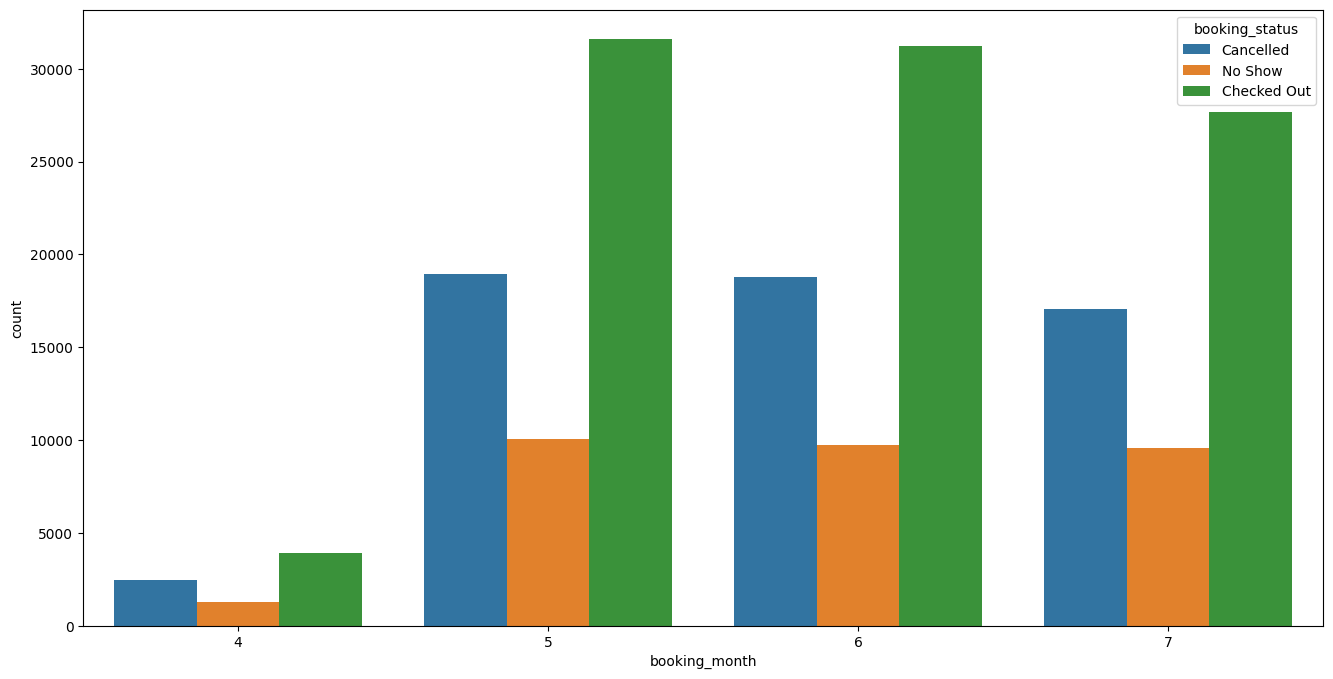

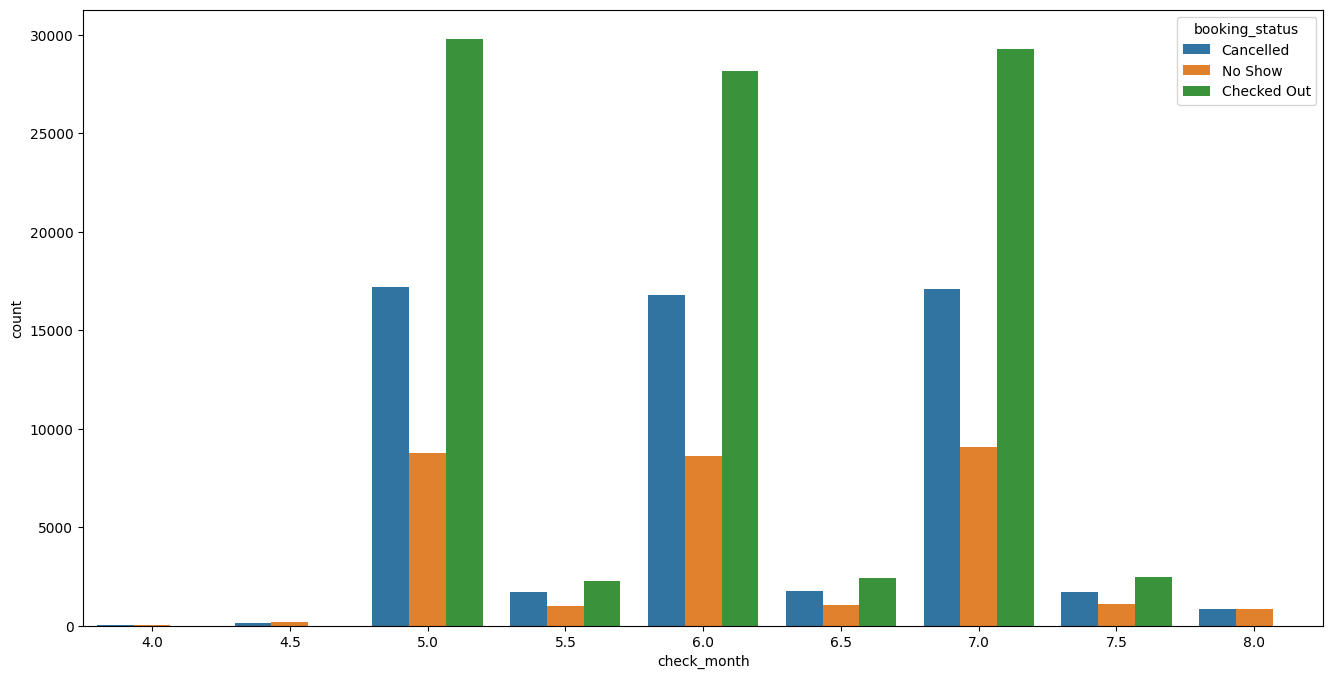

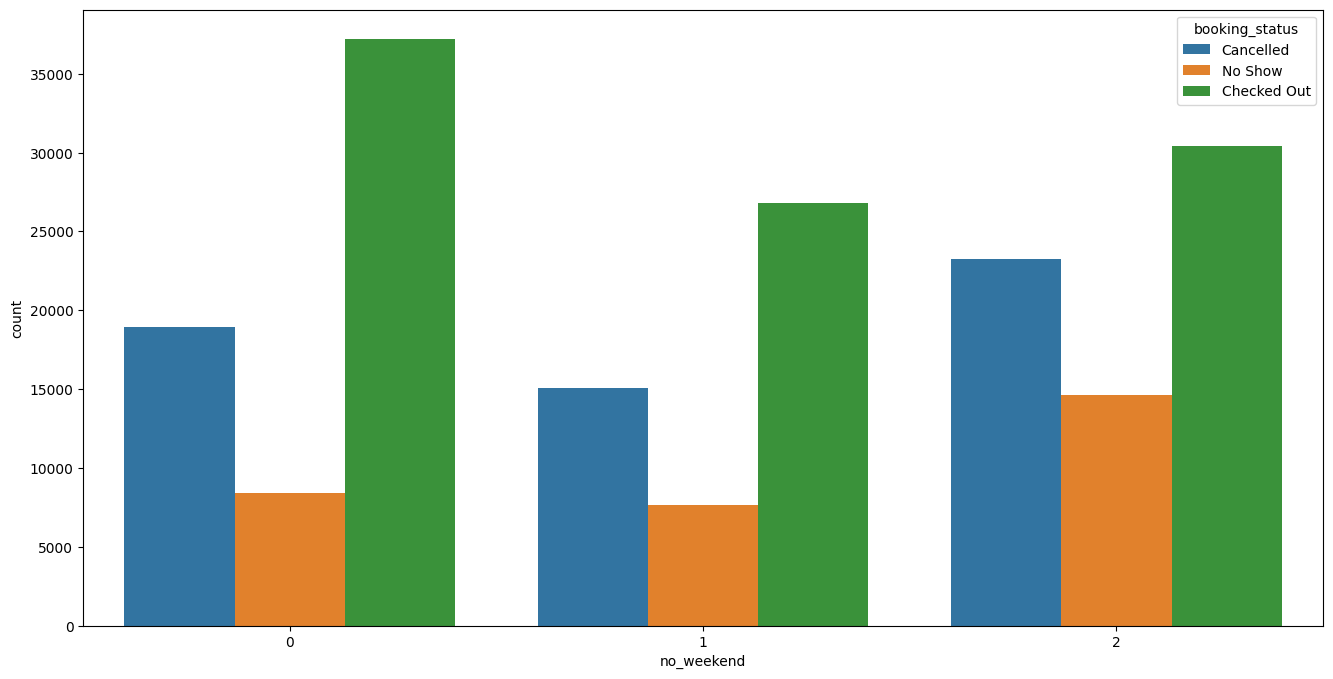

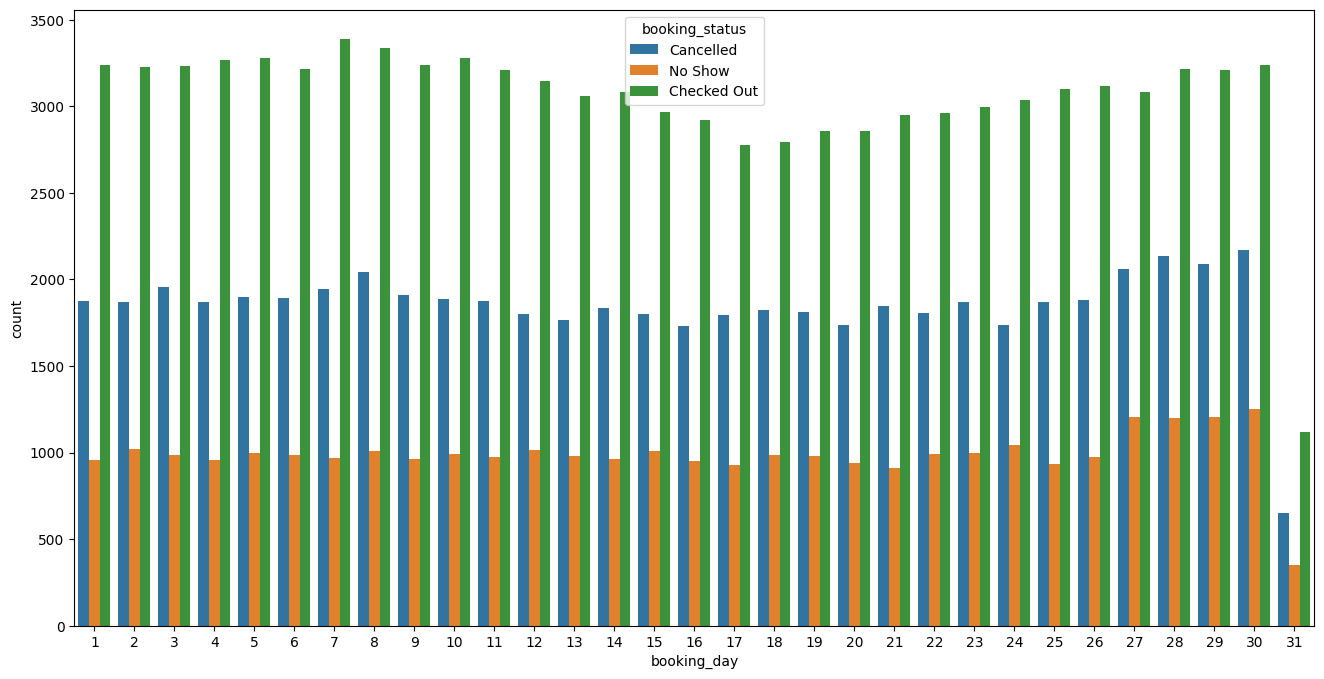

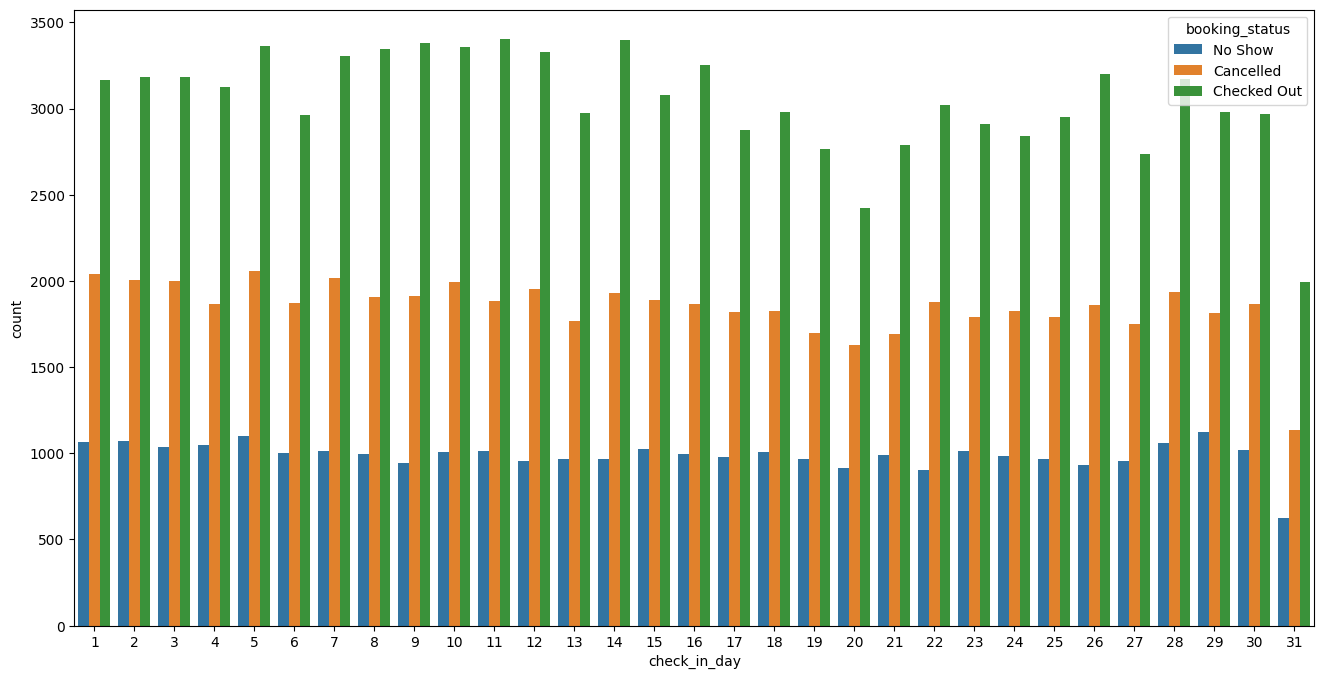

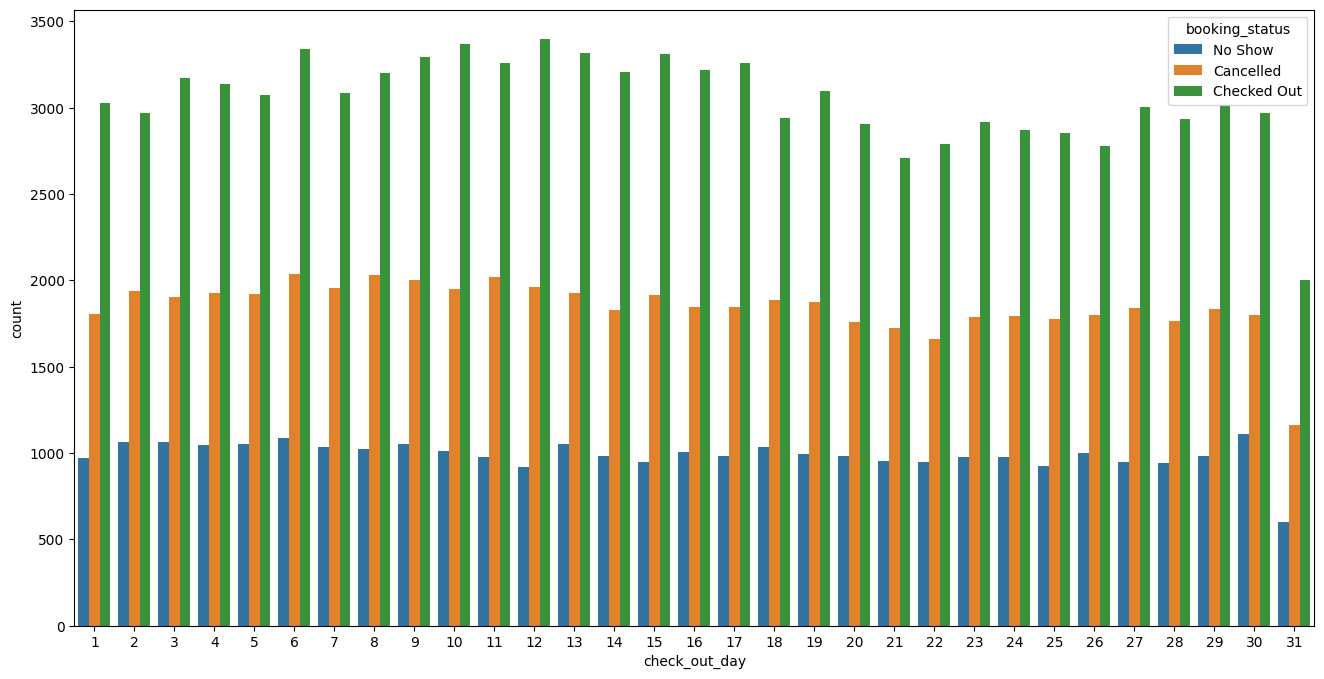

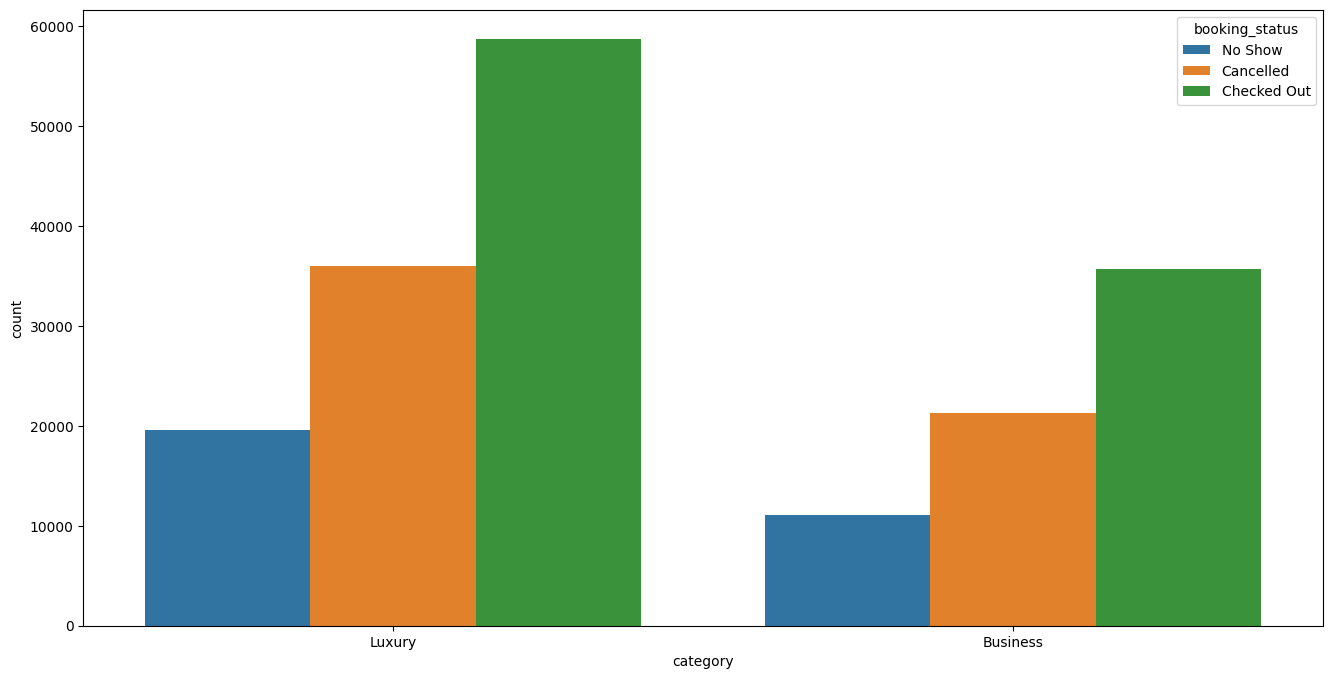

In [31]:
for column in data_set.columns:
    if (column!='revenue_generated' and column!='rev_person'):
        plt.figure(figsize=(16,8))
        sns.countplot(data_set,x=column,hue='booking_status')
        plt.show()

<Axes: ylabel='count'>

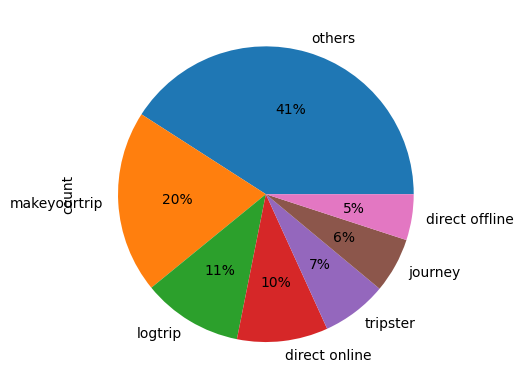

In [32]:
data_set.booking_platform.value_counts().plot(kind='pie',autopct='%1.0f%%')

<Axes: ylabel='count'>

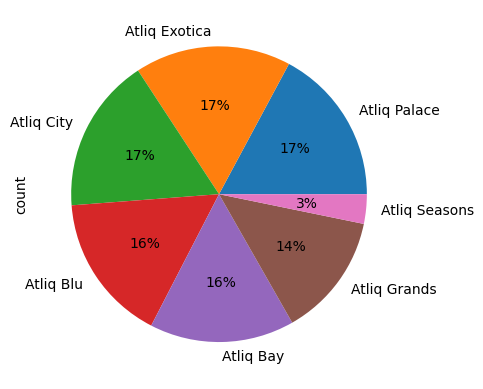

In [33]:
data_set.property_name.value_counts().plot(kind='pie',autopct='%1.0f%%')

<Axes: ylabel='count'>

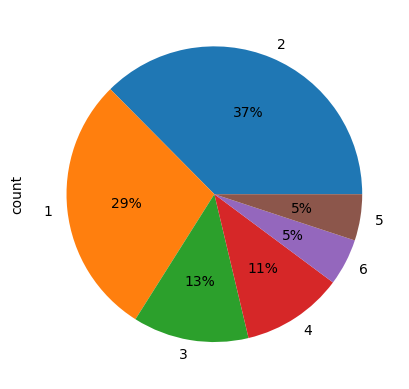

In [34]:
data_set.no_guests.value_counts().plot(kind='pie',autopct='%1.0f%%')

<Axes: ylabel='count'>

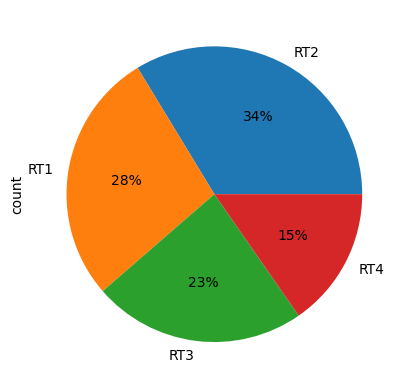

In [35]:
data_set.room_category.value_counts().plot(kind='pie',autopct='%1.0f%%')

<Axes: ylabel='count'>

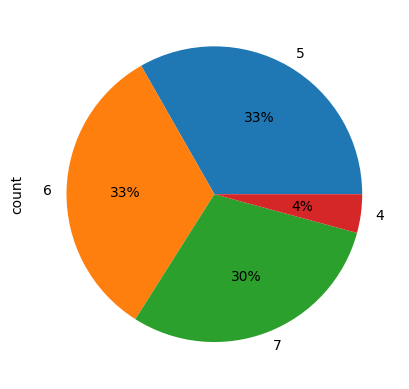

In [36]:
data_set.booking_month.value_counts().plot(kind='pie',autopct='%1.0f%%')

<Axes: ylabel='count'>

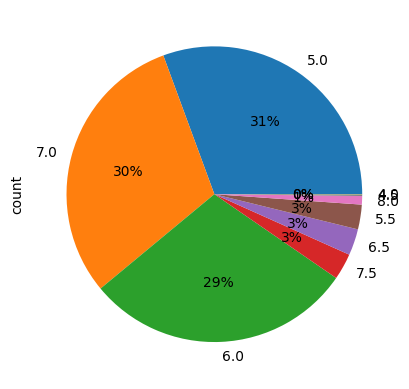

In [37]:
data_set.check_month.value_counts().plot(kind='pie',autopct='%1.0f%%')

<Axes: ylabel='count'>

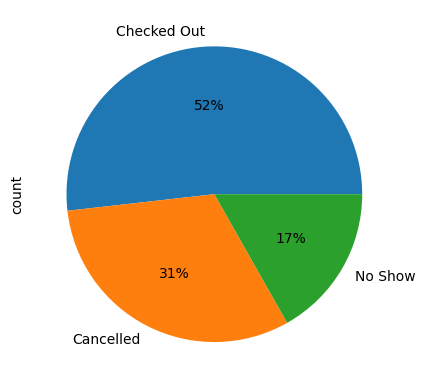

In [38]:
data_set.booking_status.value_counts().plot(kind='pie',autopct='%1.0f%%')

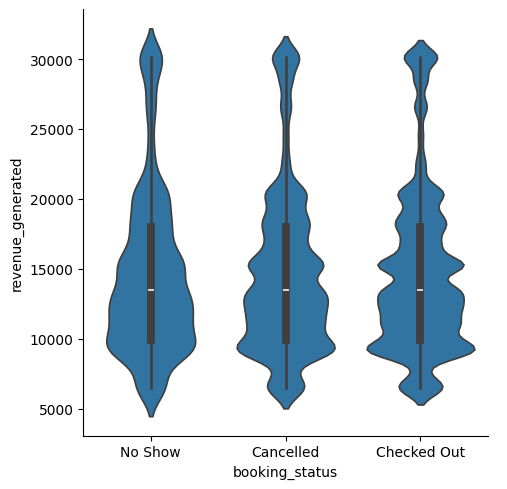

In [39]:
sns.catplot(y= 'revenue_generated', x = 'booking_status', data = data_set, kind = 'violin')

<h1>Splitting the dataset into input and output set</h1>

In [40]:
data_set["booking_status"]=data_set["booking_status"].map({'Checked Out':1,'No Show':0,'Cancelled':0})

In [41]:
#Feature Selection
data_set_X=data_set.drop(columns='booking_status')
data_set_Y=data_set['booking_status']

In [42]:
data_set_X.head()

,no_guests,room_category,property_id,booking_platform,revenue_generated,property_name,city,no_days_book_to_checkin,no_days_checkin_checkout,rev_person,booking_month,check_month,no_weekend,booking_day,check_in_day,check_out_day,category
0,4,RT2,18561,NaN,NaN,Atliq Blu,Hyderabad,7,5,NaN,5,5.0,2,16,23,28,Luxury
1,4,RT4,17558,NaN,NaN,Atliq Grands,Mumbai,2,4,NaN,6,6.0,2,14,16,20,Luxury
2,2,RT3,18560,NaN,NaN,Atliq City,Hyderabad,3,5,NaN,7,7.0,2,15,18,23,Business
3,4,RT3,16562,NaN,NaN,Atliq Bay,Delhi,4,2,NaN,5,6.0,1,31,4,6,Luxury
4,3,RT2,16559,NaN,NaN,Atliq Exotica,Delhi,5,2,NaN,6,7.0,0,30,5,7,Luxury


In [43]:
data_set_X=data_set_X.drop(columns=['property_id','booking_platform','revenue_generated','rev_person'])

# Splitting Data

In [44]:
train_X_raw,test_X_raw,train_Y,test_Y=train_test_split(data_set_X,data_set_Y,train_size=0.7,random_state=42,stratify=data_set_Y)
val_X_raw,test_X_raw,val_Y,test_Y=train_test_split(test_X_raw,test_Y,train_size=0.5,random_state=42,stratify=test_Y)

# Encoding Categorical Variables

In [45]:
encoder = ce.OneHotEncoder()
train_X_encoded=encoder.fit_transform(train_X_raw,train_Y)
val_X_encoded=encoder.transform(val_X_raw)
test_X_encoded=encoder.transform(test_X_raw)

# Scaling Numerical Features:

In [46]:
data_set_X.head()

,no_guests,room_category,property_name,city,no_days_book_to_checkin,no_days_checkin_checkout,booking_month,check_month,no_weekend,booking_day,check_in_day,check_out_day,category
0,4,RT2,Atliq Blu,Hyderabad,7,5,5,5.0,2,16,23,28,Luxury
1,4,RT4,Atliq Grands,Mumbai,2,4,6,6.0,2,14,16,20,Luxury
2,2,RT3,Atliq City,Hyderabad,3,5,7,7.0,2,15,18,23,Business
3,4,RT3,Atliq Bay,Delhi,4,2,5,6.0,1,31,4,6,Luxury
4,3,RT2,Atliq Exotica,Delhi,5,2,6,7.0,0,30,5,7,Luxury


# Oversampling

In [47]:
# smote=SMOTE(random_state=0)
# train_X_SMOTE,train_Y_SMOTE=smote.fit_resample(train_X_encoded,train_Y)
train_X_SMOTE=train_X_encoded
train_Y_SMOTE=train_Y

<h1>Feature Selection</h1>

In [48]:
train_X_SMOTE

,no_guests,room_category_1,room_category_2,room_category_3,room_category_4,property_name_1,property_name_2,property_name_3,property_name_4,property_name_5,...,no_days_book_to_checkin,no_days_checkin_checkout,booking_month,check_month,no_weekend,booking_day,check_in_day,check_out_day,category_1,category_2
92457,3,1,0,0,0,1,0,0,0,0,...,4,3,5,5.5,1,27,31,3,1,0
20109,3,0,1,0,0,0,1,0,0,0,...,7,5,6,7.0,2,29,6,11,1,0
31620,5,0,0,1,0,0,0,1,0,0,...,8,4,7,8.0,0,30,7,11,0,1
93839,2,1,0,0,0,0,0,0,1,0,...,1,1,5,6.0,0,31,1,2,0,1
133892,4,0,0,0,1,0,0,1,0,0,...,1,4,6,6.5,2,27,28,2,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120369,2,0,0,1,0,0,0,1,0,0,...,4,1,6,6.0,1,14,18,19,0,1
9974,1,0,1,0,0,1,0,0,0,0,...,7,2,6,7.0,0,26,3,5,1,0
132624,3,1,0,0,0,0,1,0,0,0,...,4,2,6,6.0,0,23,27,29,1,0
177074,1,0,1,0,0,0,0,1,0,0,...,2,4,7,7.5,2,26,28,1,0,1


<Axes: >

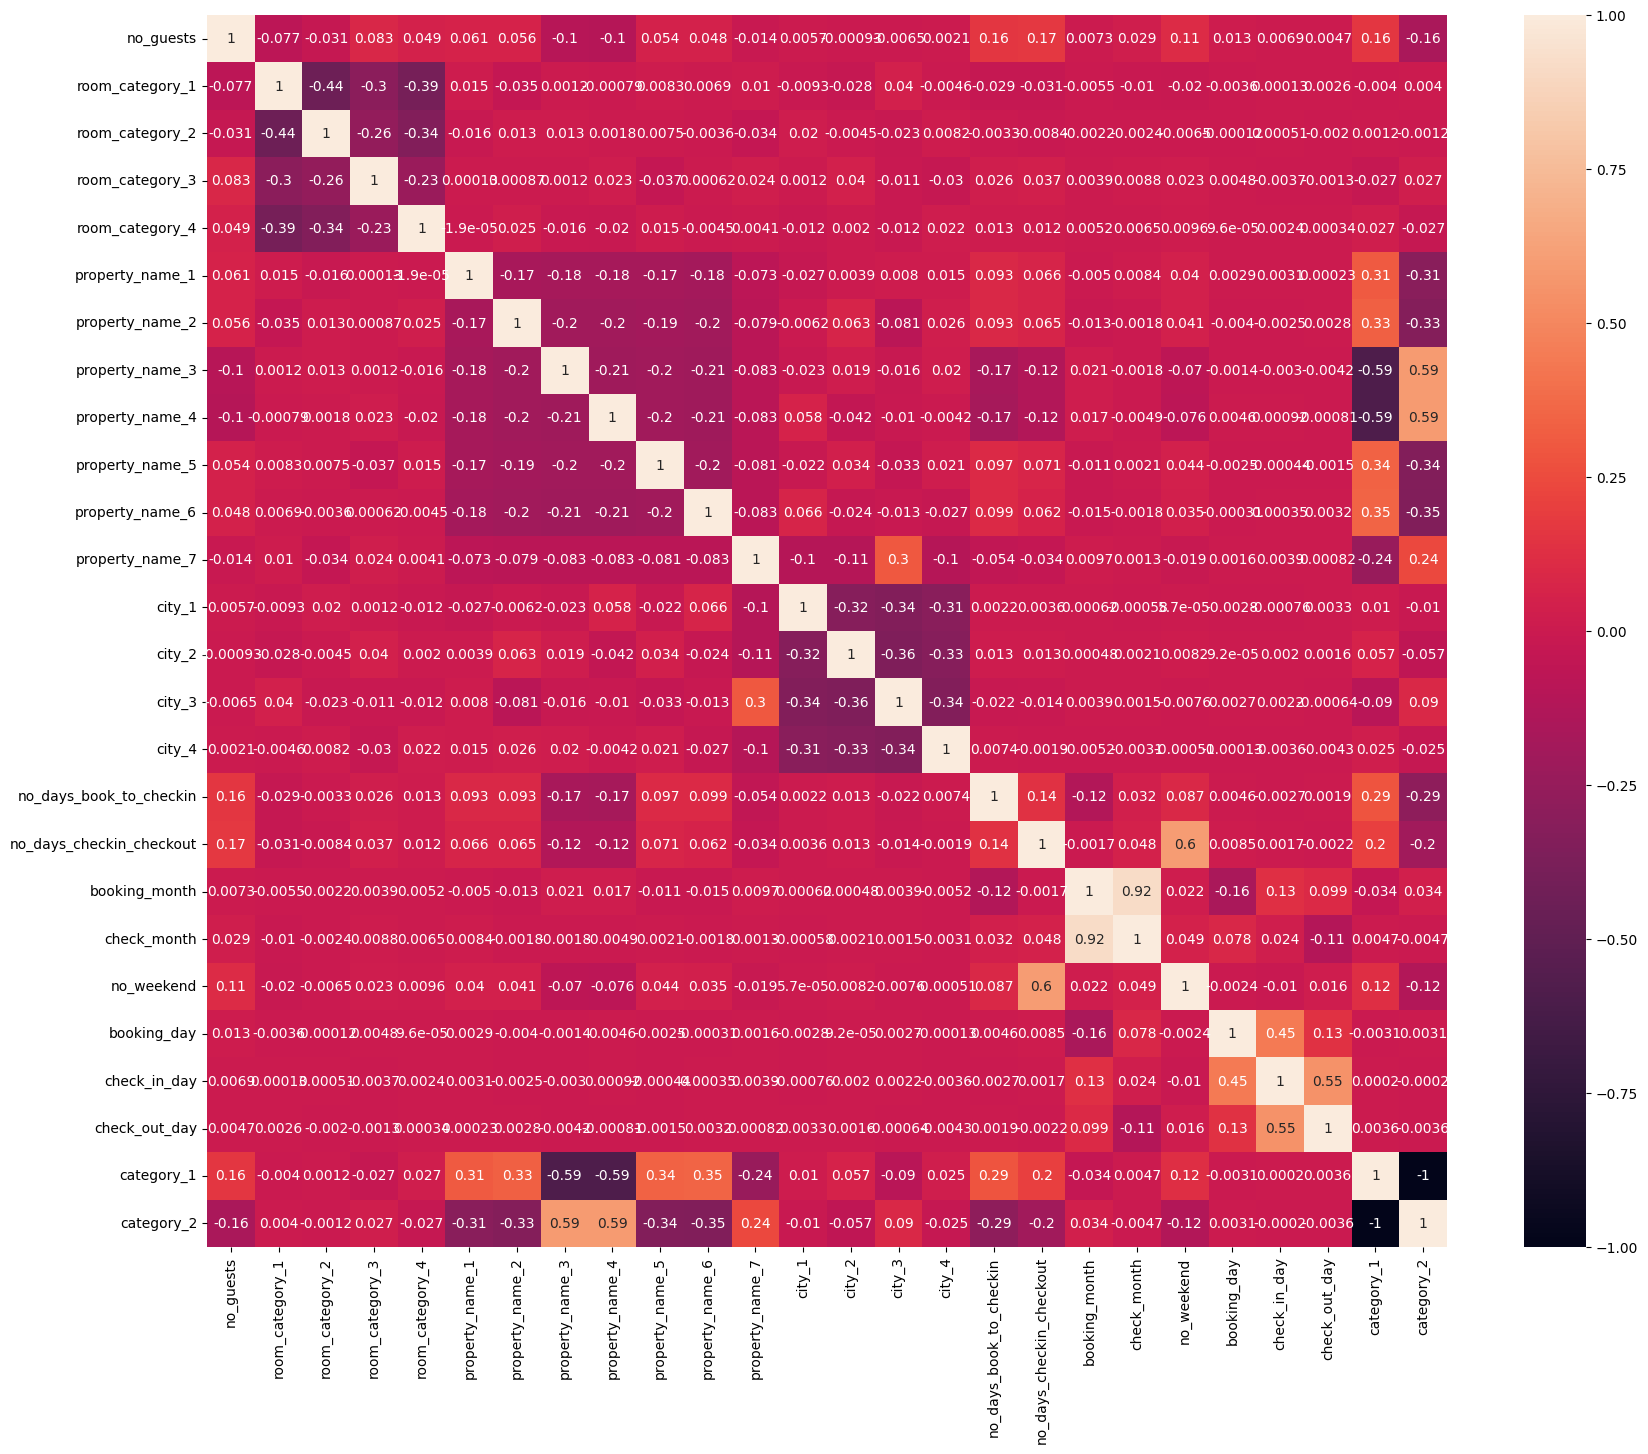

In [49]:
corelation = train_X_SMOTE.corr()
plt.figure(figsize=(20,16))
sns.heatmap(corelation, xticklabels=corelation.columns, yticklabels=corelation.columns,annot=True)

In [50]:
def correlation(dataset,threshold):
    col_corr=set()
    corr_matrix=dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j])>=threshold:
                colname=corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [51]:
corr_features=correlation(train_X_SMOTE,0.7)
train_X_corr=train_X_SMOTE.drop(corr_features,axis=1)
val_X_corr=val_X_encoded.drop(corr_features,axis=1)
test_X_corr=test_X_encoded.drop(corr_features,axis=1)
corr_features

{'category_2', 'check_month'}

In [52]:
train_X_corr.head()

,no_guests,room_category_1,room_category_2,room_category_3,room_category_4,property_name_1,property_name_2,property_name_3,property_name_4,property_name_5,...,city_3,city_4,no_days_book_to_checkin,no_days_checkin_checkout,booking_month,no_weekend,booking_day,check_in_day,check_out_day,category_1
92457,3,1,0,0,0,1,0,0,0,0,...,0,0,4,3,5,1,27,31,3,1
20109,3,0,1,0,0,0,1,0,0,0,...,0,0,7,5,6,2,29,6,11,1
31620,5,0,0,1,0,0,0,1,0,0,...,0,0,8,4,7,0,30,7,11,0
93839,2,1,0,0,0,0,0,0,1,0,...,0,0,1,1,5,0,31,1,2,0
133892,4,0,0,0,1,0,0,1,0,0,...,0,0,1,4,6,2,27,28,2,0


In [53]:
train_X_corr.shape

(127609, 24)

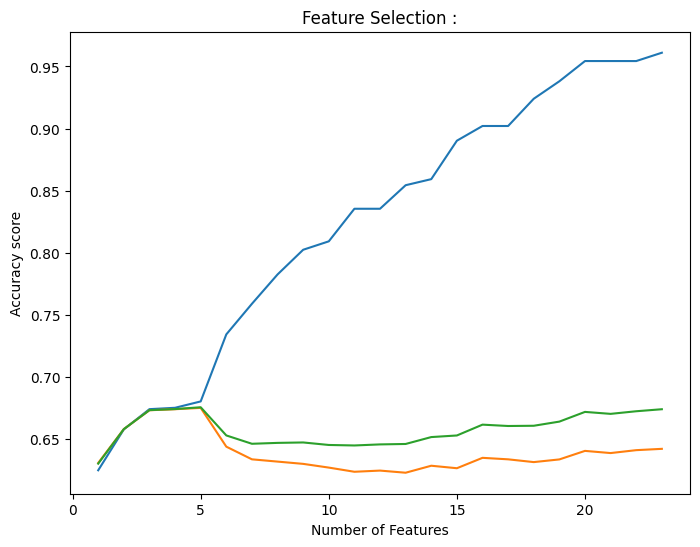

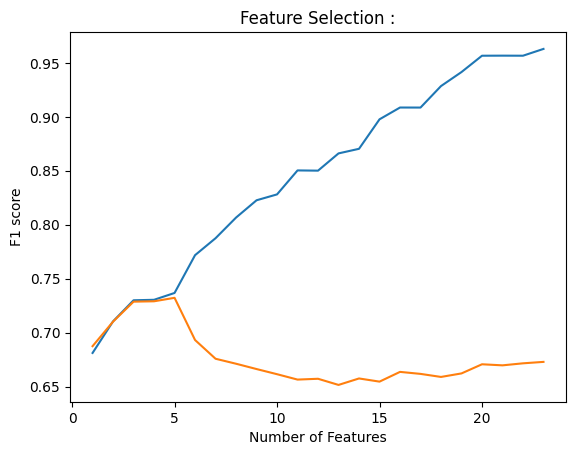

In [54]:
train_acc = {}
test_acc = {}
train_f1 = {}
test_f1 = {}
acc_per_features = {}
variable = np.arange(1,24)
for i in variable:
    sel_five_cols=SelectKBest(chi2, k=i)
    sel_five_cols.fit(train_X_corr,train_Y_SMOTE)
    train_X_chi=train_X_corr[train_X_corr.columns[sel_five_cols.get_support()]]
    test_X_chi=test_X_corr[test_X_corr.columns[sel_five_cols.get_support()]]
    model= RandomForestClassifier()
    model.fit(train_X_chi,train_Y_SMOTE)
    pred_train_Y = model.predict(train_X_chi)
    pred_Y = model.predict(test_X_chi)
    train_acc[i-1]=accuracy_score(pred_train_Y,train_Y_SMOTE)
    test_acc[i-1]=accuracy_score(pred_Y,test_Y)
    acc_per_features[i-1]=(0.1*train_acc[i-1])+(0.9*test_acc[i-1])
    train_f1[i-1]=f1_score(pred_train_Y,train_Y_SMOTE)
    test_f1[i-1]=f1_score(pred_Y,test_Y)
plt.figure(figsize=(8,6))
plt.title("Feature Selection :")
plt.plot(variable, train_acc.values(), label="Training Accuracy score")
plt.plot(variable, test_acc.values(), label="Testing Accuracy score")
plt.plot(variable, acc_per_features.values(), label="Selection Accuracy score")
plt.xlabel("Number of Features")
plt.ylabel("Accuracy score")
plt.show()
plt.title("Feature Selection :")
plt.plot(variable, train_f1.values(), label="Training F1 score")
plt.plot(variable, test_f1.values(), label="Testing F1 score")
plt.xlabel("Number of Features")
plt.ylabel("F1 score")
plt.show()

In [55]:
print(acc_per_features)
acc_value=[]
for i in variable:
  acc_value.append(acc_per_features[i-1])
max_acc_chi=max(acc_value)
sel_features_chi=acc_value.index(max_acc_chi)
print("The number of features which are selected for training the model are ",sel_features_chi, "which gives an accuracy of ",max_acc_chi)

{0: 0.6300283195212567, 1: 0.657845017859854, 2: 0.6731301670494888, 3: 0.6739976271073561, 4: 0.6754645658932628, 5: 0.6527589516348197, 6: 0.6460403975610798, 7: 0.6467582883442298, 8: 0.6471015973972508, 9: 0.6450814835566365, 10: 0.6446780414632295, 11: 0.6455337424798315, 12: 0.6458833162986858, 13: 0.6514406929661881, 14: 0.652726732802263, 15: 0.6614491371134232, 16: 0.6603614877663161, 17: 0.660548867782109, 18: 0.6638996423870551, 19: 0.6717154307577764, 20: 0.6701364586786056, 21: 0.6722412323549753, 22: 0.6738672508296186}
The number of features which are selected for training the model are  4 which gives an accuracy of  0.6754645658932628


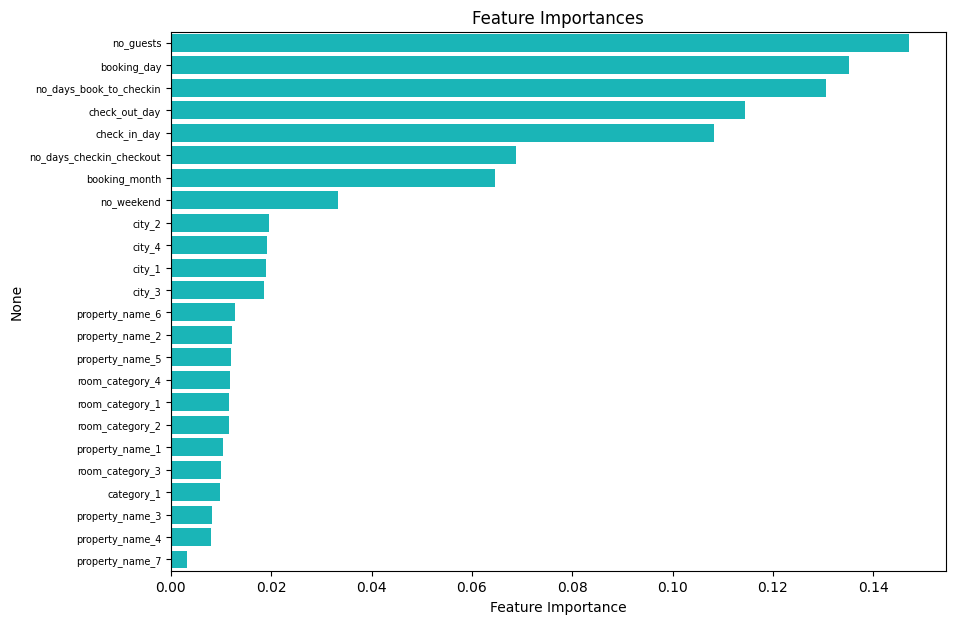

In [56]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
rdc=RandomForestClassifier(random_state=0, n_jobs=-1)
rdc.fit(train_X_corr,train_Y_SMOTE)
feature_importances = rdc.feature_importances_
sorted_indices = np.argsort(feature_importances)[::-1]
plt.figure(figsize=(10, 7))
sns.barplot(x=feature_importances[sorted_indices], y=train_X_corr.columns[sorted_indices], color='darkturquoise')
plt.xlabel('Feature Importance')
plt.title('Feature Importances')
plt.yticks(fontsize=7)
plt.show()

In [57]:
train_acc = {}
test_acc = {}
train_f1 = {}
test_f1 = {}
acc_per_features = {}
for i in range (2,len(sorted_indices)):
    train_X_rfc = train_X_corr.iloc[:, sorted_indices[0:i]]
    test_X_rfc = test_X_corr.iloc[:, sorted_indices[0:i]]
    model = RandomForestClassifier()
    model.fit(train_X_rfc,train_Y_SMOTE)
    pred_train_Y = model.predict(train_X_rfc)
    pred_Y = model.predict(test_X_rfc)
    train_acc[i-1]=accuracy_score(pred_train_Y,train_Y_SMOTE)
    test_acc[i-1]=accuracy_score(pred_Y,test_Y)
    acc_per_features[i-1]=(0.1*train_acc[i-1])+(0.9*test_acc[i-1])
    train_f1[i-1]=f1_score(pred_train_Y,train_Y_SMOTE)
    test_f1[i-1]=f1_score(pred_Y,test_Y)

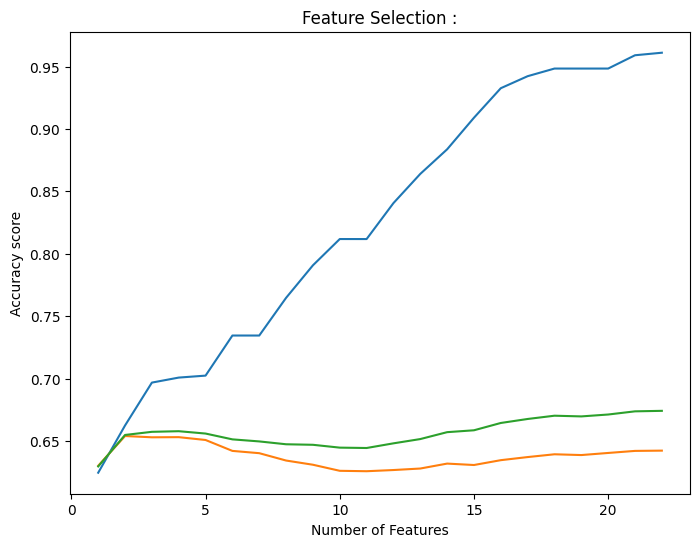

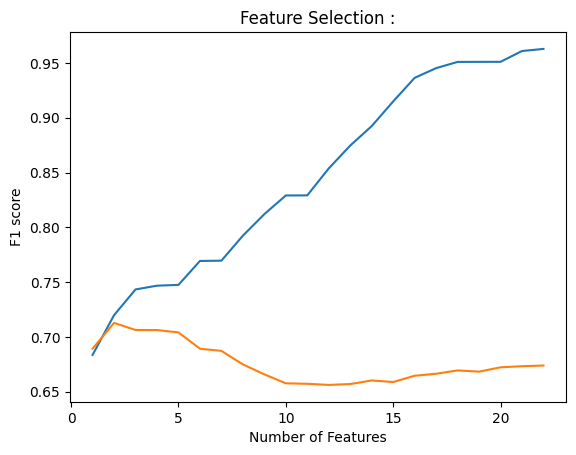

In [58]:
variable = np.arange(1,23)
plt.figure(figsize=(8,6))
plt.title("Feature Selection :")
plt.plot(variable, train_acc.values(), label="Training Accuracy score")
plt.plot(variable, test_acc.values(), label="Testing Accuracy score")
plt.plot(variable, acc_per_features.values(), label="Selection Accuracy score")
plt.xlabel("Number of Features")
plt.ylabel("Accuracy score")
plt.show()
plt.title("Feature Selection :")
plt.plot(variable, train_f1.values(), label="Training F1 score")
plt.plot(variable, test_f1.values(), label="Testing F1 score")
plt.xlabel("Number of Features")
plt.ylabel("F1 score")
plt.show()

In [59]:
print(acc_per_features)
acc_value=[]
for i in range (2,len(sorted_indices)):
  acc_value.append(acc_per_features[i-1])
max_acc_rfc=max(acc_value)
sel_features_rfc=acc_value.index(max_acc_rfc)
print("The number of features which are selected for training the model are ",sel_features_rfc, "which gives an accuracy of ",max_acc_rfc)

{1: 0.6296976364580669, 2: 0.6549080729413115, 3: 0.6574196921999085, 4: 0.6579196525514761, 5: 0.6560366471438187, 6: 0.6513821523452272, 7: 0.6497357898233596, 8: 0.6474564053467886, 9: 0.6470333721587097, 10: 0.6447602159107879, 11: 0.6444624444251597, 12: 0.6481980363585464, 13: 0.6516232951219174, 14: 0.6571462586912153, 15: 0.6586556019308545, 16: 0.6645092661011905, 17: 0.6677095679456695, 18: 0.6703284163306948, 19: 0.6697681358683605, 20: 0.6712828520799817, 21: 0.6738288449766248, 22: 0.6742292781827964}
The number of features which are selected for training the model are  21 which gives an accuracy of  0.6742292781827964


In [60]:
if (max_acc_chi > max_acc_rfc):
  sel_five_cols=SelectKBest(chi2, k=sel_features_chi)
  sel_five_cols.fit(train_X_corr,train_Y_SMOTE)
  train_X_sel=train_X_corr[train_X_corr.columns[sel_five_cols.get_support()]]
  val_X_sel=val_X_corr[val_X_corr.columns[sel_five_cols.get_support()]]
  test_X_sel=test_X_corr[test_X_corr.columns[sel_five_cols.get_support()]]
  print("Number of features : ",sel_features_chi)
else:
  train_X_sel=train_X_corr.iloc[:, sorted_indices[0:sel_features_rfc]]
  val_X_sel=val_X_corr.iloc[:, sorted_indices[0:sel_features_rfc]]
  test_X_sel=test_X_corr.iloc[:, sorted_indices[0:sel_features_rfc]]
  print("Number of features : ",sel_features_rfc)

Number of features :  4


In [61]:
print(train_X_sel.columns)
train_Y=train_Y_SMOTE

Index(['no_guests', 'no_days_book_to_checkin', 'no_days_checkin_checkout',
       'no_weekend'],
      dtype='object')


In [62]:
sel_feat=list(train_X_sel.columns)

In [63]:
f = open("selected_features.txt", "w")
f.write(str(data_set.values.tolist()))
f.close()

In [64]:
scaler=StandardScaler()
train_X=scaler.fit_transform(train_X_sel)
val_X=scaler.transform(val_X_sel)
test_X=scaler.transform(test_X_sel)

In [65]:
train_X

array([[ 0.41537843,  0.20127902,  0.18428355, -0.02336222],
       [ 0.41537843,  1.30626427,  1.29737293,  1.14850493],
       [ 1.84663918,  1.67459268,  0.74082824, -1.19522937],
       ...,
       [ 0.41537843,  0.20127902, -0.37226114, -1.19522937],
       [-1.01588232, -0.53537782,  0.74082824,  1.14850493],
       [-1.01588232, -0.53537782, -0.92880584,  1.14850493]])

<h3> Choosing the Model for Classification Model </h1>

In [66]:
from sklearn.utils import class_weight
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, KFold
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay,roc_curve,roc_auc_score,mean_absolute_error
dtc=DecisionTreeClassifier(random_state=0)

In [67]:
def model_analyze(model):
    model.fit(train_X,train_Y)
    pred_Y = model.predict(test_X)
    pred_train_Y = model.predict(train_X)
    print("\n--------------------Training Set--------------------\n")
    print(classification_report(train_Y,pred_train_Y))
    print("\n----------------------Test Set----------------------\n")
    print(classification_report(test_Y, pred_Y))
    ConfusionMatrixDisplay.from_estimator(model,test_X,test_Y,colorbar=True)
    plt.title(" Confusion Matrix")
    plt.show()
    model_train_auc = roc_auc_score(train_Y, pred_train_Y)
    print('AUC: %.3f' % model_train_auc)
    model_train_fpr, model_train_tpr, model_train_thresholds = roc_curve(train_Y, pred_train_Y)
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.plot(model_train_fpr, model_train_tpr)
    plt.title(" ROC Curve for Train Data ")
    plt.show()
    model_test_auc = roc_auc_score(test_Y, pred_Y)
    print('AUC: %.3f' % model_test_auc)
    model_train_fpr, model_train_tpr, model_train_thresholds = roc_curve(test_Y, pred_Y)
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.plot(model_train_fpr, model_train_tpr)
    plt.title(" ROC Curve for Test Data ")

0.7133491305237414

--------------------Training Set--------------------

              precision    recall  f1-score   support

           0       0.75      0.49      0.59     61522
           1       0.64      0.85      0.73     66087

    accuracy                           0.68    127609
   macro avg       0.70      0.67      0.66    127609
weighted avg       0.69      0.68      0.66    127609


----------------------Test Set----------------------

              precision    recall  f1-score   support

           0       0.75      0.49      0.59     13184
           1       0.64      0.84      0.73     14162

    accuracy                           0.67     27346
   macro avg       0.69      0.67      0.66     27346
weighted avg       0.69      0.67      0.66     27346



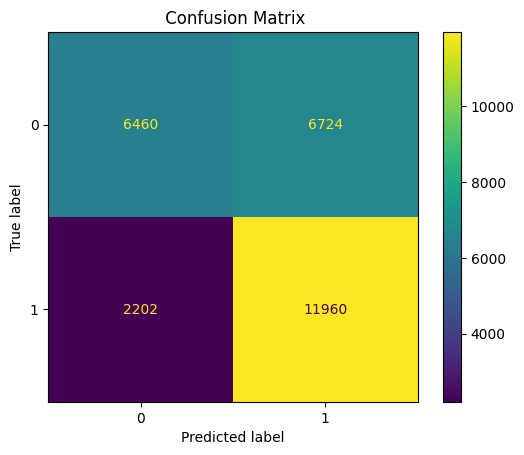

AUC: 0.669


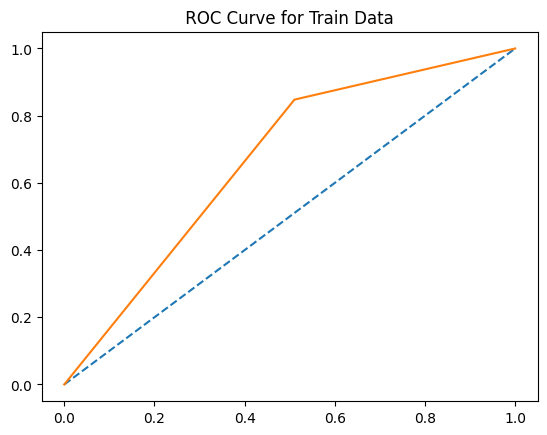

AUC: 0.667


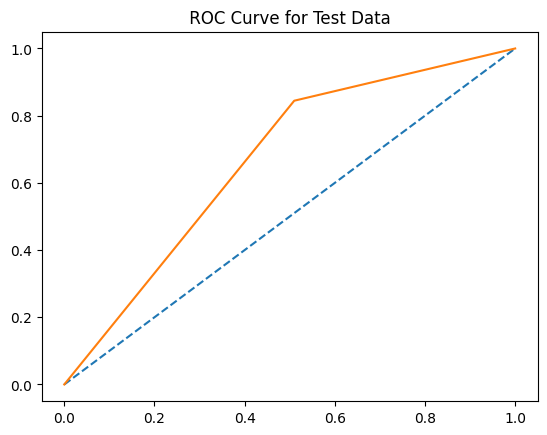

In [68]:
kf = KFold(n_splits=5, random_state=None)
result = cross_val_score(dtc, val_X, val_Y, cv=kf, scoring='f1')
print(result.mean())
model_analyze(dtc)

C:\Users\donku\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



--------------------Training Set--------------------

              precision    recall  f1-score   support

           0       0.75      0.49      0.59     61522
           1       0.64      0.85      0.73     66087

    accuracy                           0.68    127609
   macro avg       0.70      0.67      0.66    127609
weighted avg       0.69      0.68      0.66    127609


----------------------Test Set----------------------

              precision    recall  f1-score   support

           0       0.75      0.49      0.59     13184
           1       0.64      0.85      0.73     14162

    accuracy                           0.67     27346
   macro avg       0.69      0.67      0.66     27346
weighted avg       0.69      0.67      0.66     27346



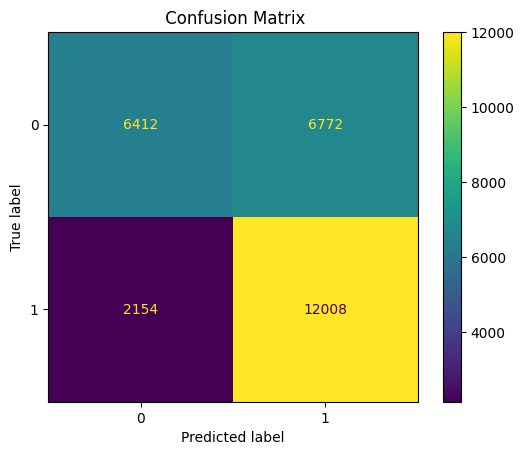

AUC: 0.669


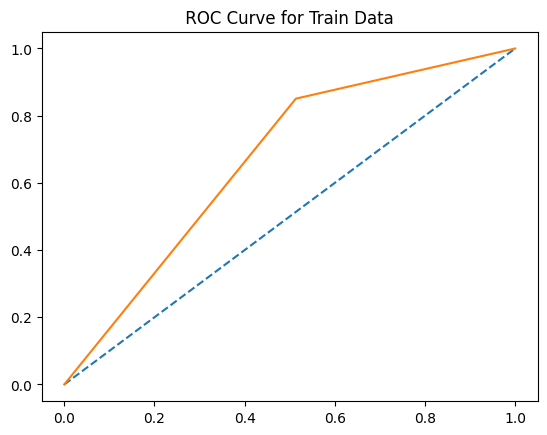

AUC: 0.667


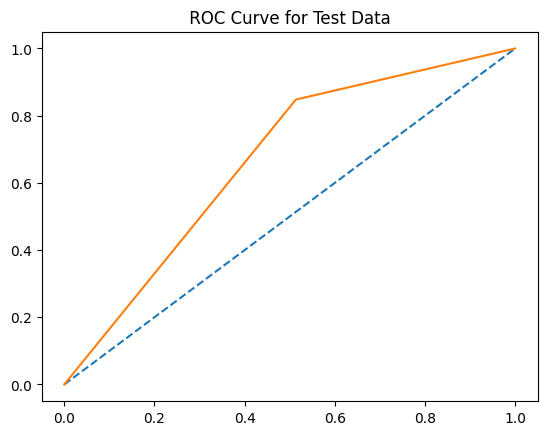

In [69]:
ada=AdaBoostClassifier(estimator=dtc)
model_analyze(ada)


--------------------Training Set--------------------

              precision    recall  f1-score   support

           0       0.75      0.49      0.59     61522
           1       0.64      0.85      0.73     66087

    accuracy                           0.68    127609
   macro avg       0.70      0.67      0.66    127609
weighted avg       0.69      0.68      0.66    127609


----------------------Test Set----------------------

              precision    recall  f1-score   support

           0       0.75      0.49      0.59     13184
           1       0.64      0.85      0.73     14162

    accuracy                           0.67     27346
   macro avg       0.69      0.67      0.66     27346
weighted avg       0.69      0.67      0.66     27346



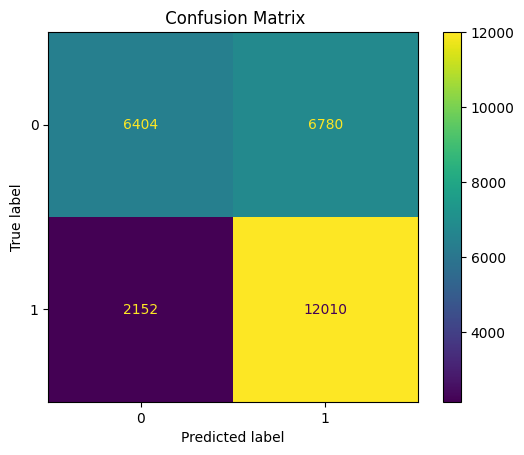

AUC: 0.668


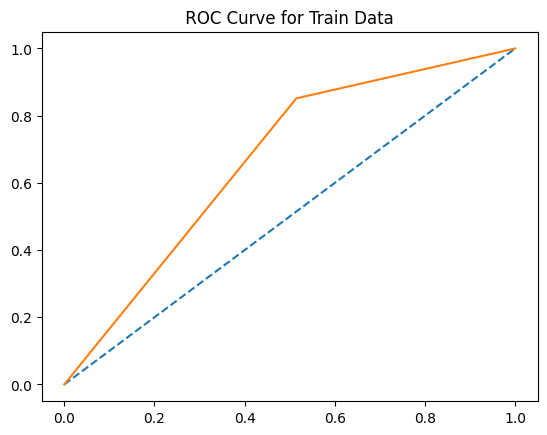

AUC: 0.667


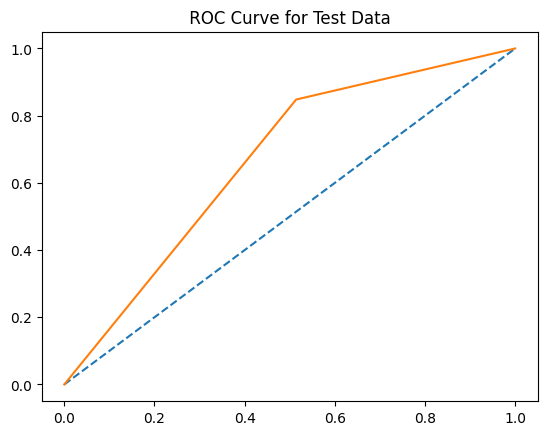

In [70]:
rdc=RandomForestClassifier(random_state=0, n_jobs=-1)
model_analyze(rdc)


--------------------Training Set--------------------

              precision    recall  f1-score   support

           0       0.75      0.49      0.59     61522
           1       0.64      0.84      0.73     66087

    accuracy                           0.67    127609
   macro avg       0.69      0.67      0.66    127609
weighted avg       0.69      0.67      0.66    127609


----------------------Test Set----------------------

              precision    recall  f1-score   support

           0       0.75      0.49      0.59     13184
           1       0.64      0.84      0.73     14162

    accuracy                           0.67     27346
   macro avg       0.69      0.67      0.66     27346
weighted avg       0.69      0.67      0.66     27346



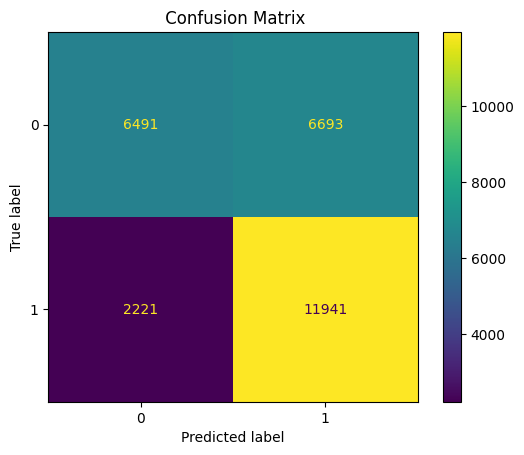

AUC: 0.667


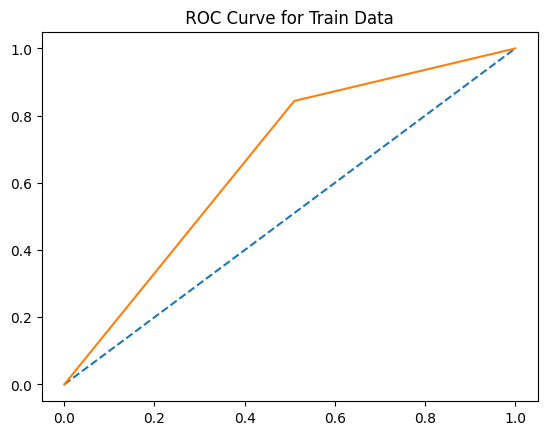

AUC: 0.668


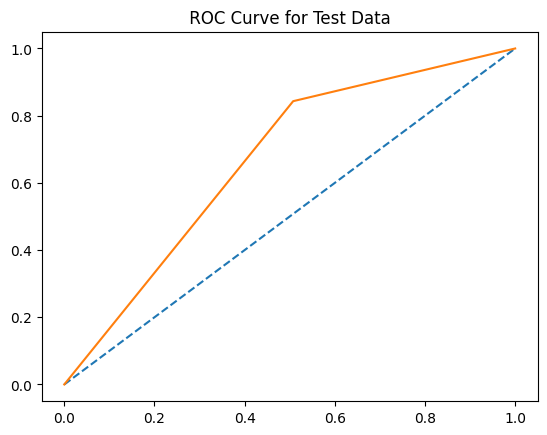

In [71]:
gb = GradientBoostingClassifier()
model_analyze(gb)


--------------------Training Set--------------------

              precision    recall  f1-score   support

           0       0.75      0.49      0.59     61522
           1       0.64      0.85      0.73     66087

    accuracy                           0.67    127609
   macro avg       0.69      0.67      0.66    127609
weighted avg       0.69      0.67      0.66    127609


----------------------Test Set----------------------

              precision    recall  f1-score   support

           0       0.75      0.49      0.59     13184
           1       0.64      0.84      0.73     14162

    accuracy                           0.67     27346
   macro avg       0.69      0.67      0.66     27346
weighted avg       0.69      0.67      0.66     27346



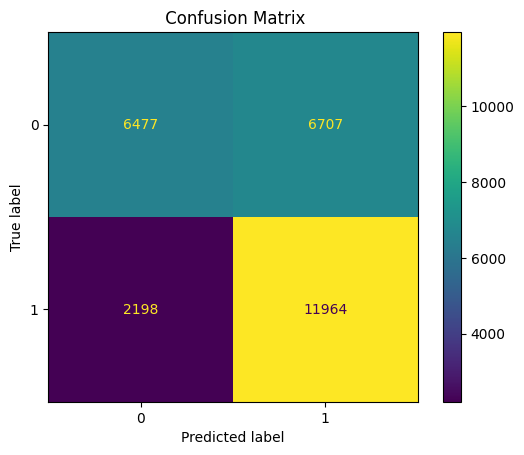

AUC: 0.668


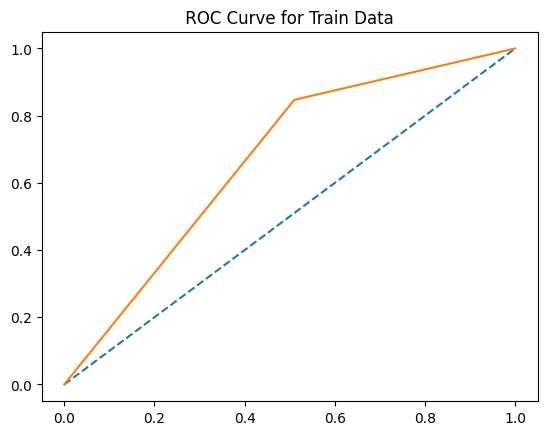

AUC: 0.668


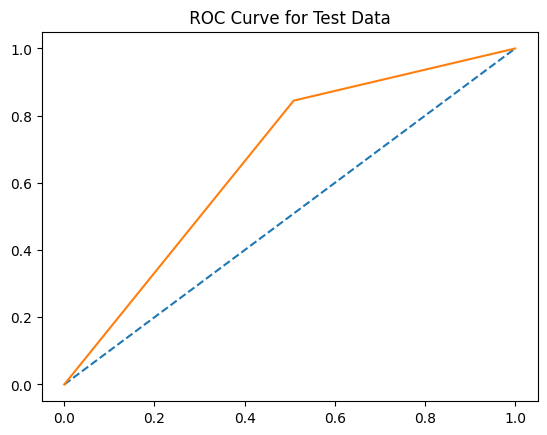

In [72]:
xgb = XGBClassifier(eval_metric='logloss', random_state=0)
model_analyze(xgb)


--------------------Training Set--------------------

              precision    recall  f1-score   support

           0       0.60      0.58      0.59     61522
           1       0.62      0.64      0.63     66087

    accuracy                           0.61    127609
   macro avg       0.61      0.61      0.61    127609
weighted avg       0.61      0.61      0.61    127609


----------------------Test Set----------------------

              precision    recall  f1-score   support

           0       0.59      0.58      0.58     13184
           1       0.62      0.63      0.62     14162

    accuracy                           0.60     27346
   macro avg       0.60      0.60      0.60     27346
weighted avg       0.60      0.60      0.60     27346



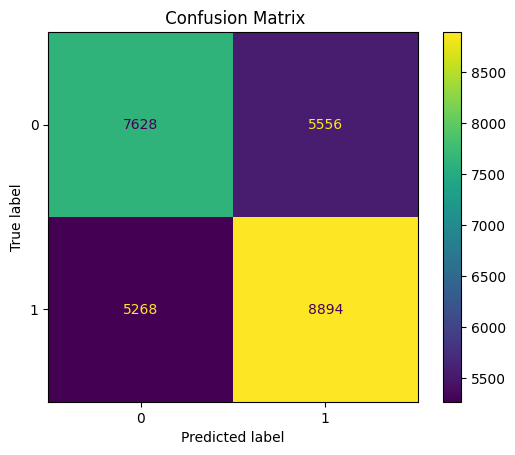

AUC: 0.607


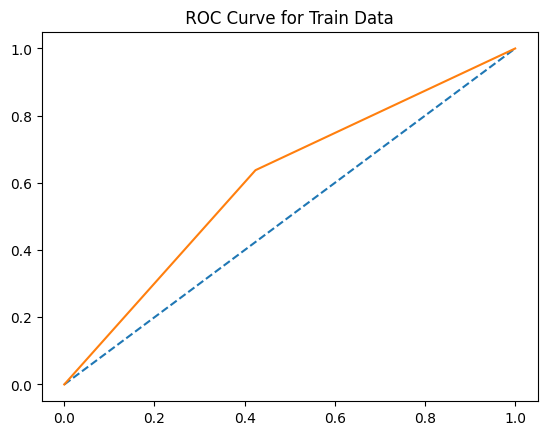

AUC: 0.603


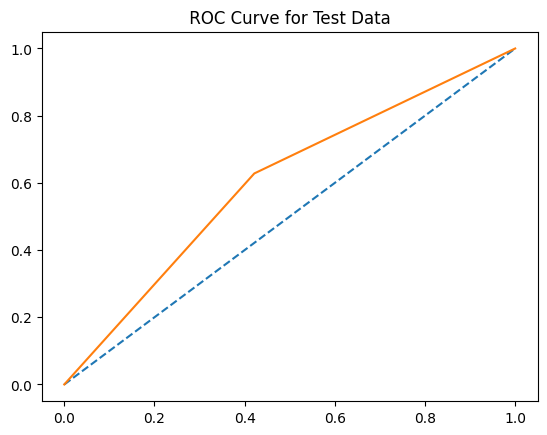

In [73]:
#kNN Nearest Neighbour
knn_model = KNeighborsClassifier(n_neighbors=3)
model_analyze(knn_model)


--------------------Training Set--------------------

              precision    recall  f1-score   support

           0       0.61      0.56      0.58     61522
           1       0.62      0.66      0.64     66087

    accuracy                           0.61    127609
   macro avg       0.61      0.61      0.61    127609
weighted avg       0.61      0.61      0.61    127609


----------------------Test Set----------------------

              precision    recall  f1-score   support

           0       0.61      0.57      0.59     13184
           1       0.62      0.67      0.64     14162

    accuracy                           0.62     27346
   macro avg       0.62      0.62      0.62     27346
weighted avg       0.62      0.62      0.62     27346



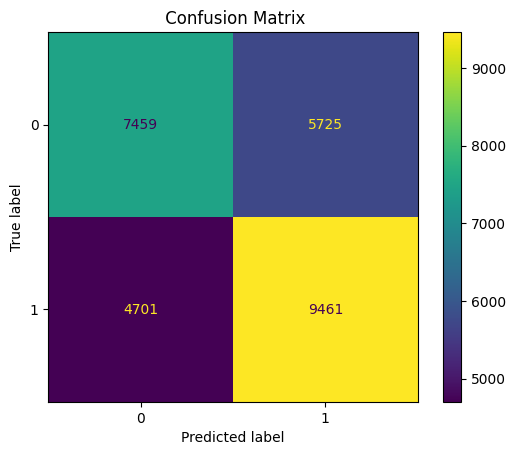

AUC: 0.612


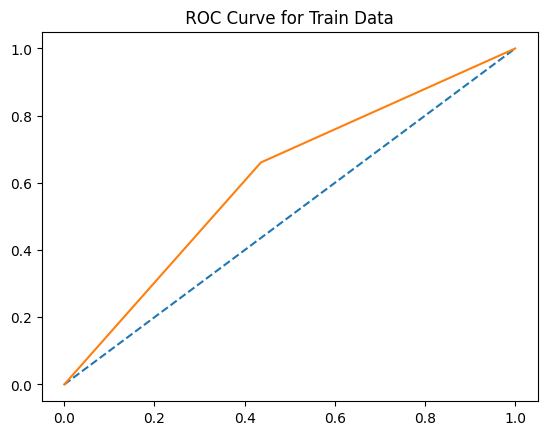

AUC: 0.617


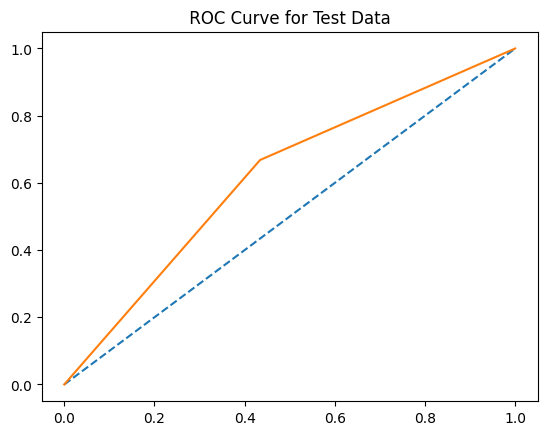

In [74]:
#Logistic Regression
log_model = LogisticRegression(class_weight="balanced")
model_analyze(log_model)


--------------------Training Set--------------------

              precision    recall  f1-score   support

           0       0.64      0.51      0.57     61522
           1       0.62      0.74      0.67     66087

    accuracy                           0.63    127609
   macro avg       0.63      0.62      0.62    127609
weighted avg       0.63      0.63      0.62    127609


----------------------Test Set----------------------

              precision    recall  f1-score   support

           0       0.65      0.51      0.57     13184
           1       0.62      0.75      0.68     14162

    accuracy                           0.63     27346
   macro avg       0.64      0.63      0.62     27346
weighted avg       0.64      0.63      0.63     27346



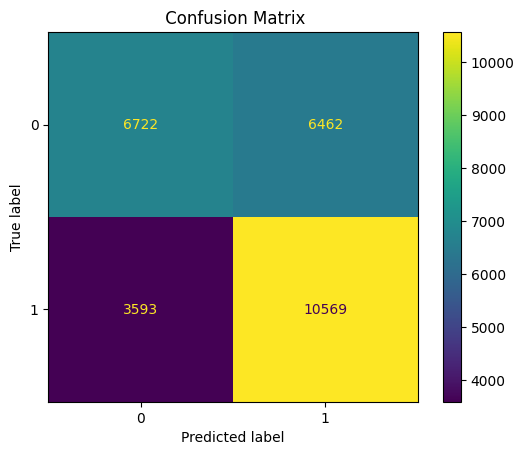

AUC: 0.623


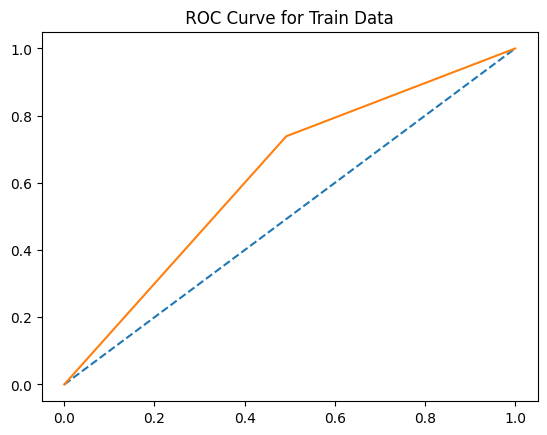

AUC: 0.628


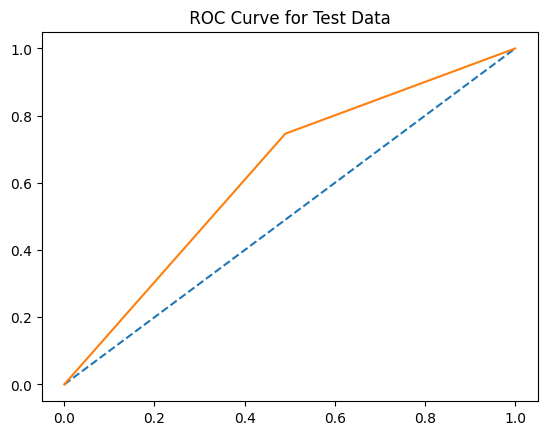

In [75]:
#Gaussian Naive Bayes
nb_model = GaussianNB()
model_analyze(nb_model)

Hyper Parameter Tuning for Random Forest
Classifier

In [76]:
auc=[]
cross_acc=[]
def rfc_objective(trial):
    # Suggest values for hyperparameters
    n_estimators = trial.suggest_int("n_estimators", 10, 200, log=True)
    max_depth = trial.suggest_int("max_depth", 2, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 18)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 18)

    # Create and fit random forest model
    model = RandomForestClassifier(
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf,
    random_state=42,
    )

    model.fit(train_X,train_Y)
    pred_Y = model.predict(test_X)
    kf = KFold(n_splits=5, random_state=None)
    result = cross_val_score(model, val_X, val_Y, cv=kf, scoring='f1')
    print(result.mean())
    mae = mean_absolute_error(test_Y, pred_Y)
    # Return MAE
    return mae

In [77]:
study = optuna.create_study(direction="minimize")
study.optimize(rfc_objective, n_trials=200, show_progress_bar=True)
print("Best trial:", study.best_trial)
print("Best hyperparameters:", study.best_params)

[I 2024-07-28 12:01:10,844] A new study created in memory with name: no-name-e83820a6-bf9b-44db-b613-19c99feecd8c


  0%|          | 0/200 [00:00<?, ?it/s]

0.7200663263737845
[I 2024-07-28 12:01:12,810] Trial 0 finished with value: 0.3364294595187596 and parameters: {'n_estimators': 45, 'max_depth': 4, 'min_samples_split': 11, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.3364294595187596.
0.7180230333185608
[I 2024-07-28 12:01:17,657] Trial 1 finished with value: 0.32615373363563227 and parameters: {'n_estimators': 67, 'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 8}. Best is trial 1 with value: 0.32615373363563227.
0.7197559963728566
[I 2024-07-28 12:01:22,631] Trial 2 finished with value: 0.3364294595187596 and parameters: {'n_estimators': 114, 'max_depth': 4, 'min_samples_split': 13, 'min_samples_leaf': 11}. Best is trial 1 with value: 0.32615373363563227.
0.7189329413365064
[I 2024-07-28 12:01:25,523] Trial 3 finished with value: 0.3259343231185548 and parameters: {'n_estimators': 41, 'max_depth': 11, 'min_samples_split': 11, 'min_samples_leaf': 11}. Best is trial 3 with value: 0.3259343231185548.
0.7167728926

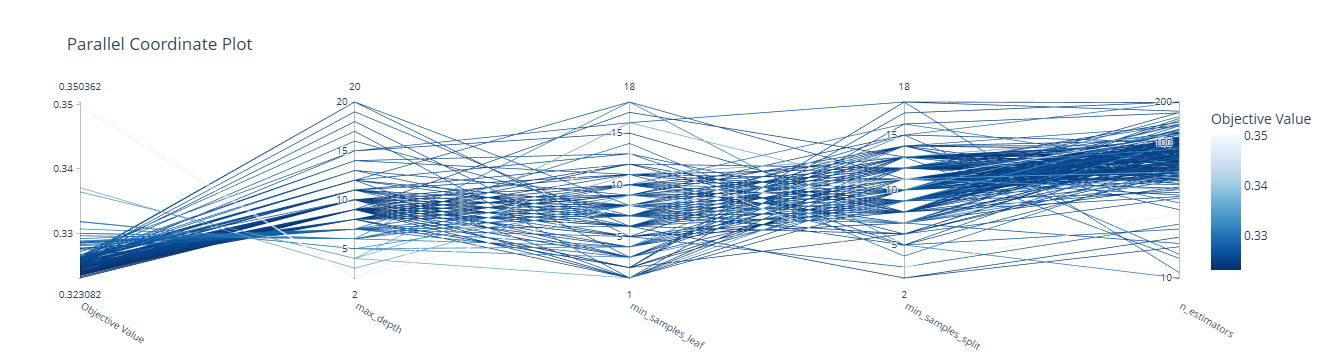

In [78]:
optuna.visualization.plot_parallel_coordinate(study)


--------------------Training Set--------------------

              precision    recall  f1-score   support

           0       0.75      0.48      0.59     61522
           1       0.64      0.85      0.73     66087

    accuracy                           0.67    127609
   macro avg       0.70      0.67      0.66    127609
weighted avg       0.69      0.67      0.66    127609


----------------------Test Set----------------------

              precision    recall  f1-score   support

           0       0.75      0.49      0.59     13184
           1       0.64      0.85      0.73     14162

    accuracy                           0.68     27346
   macro avg       0.70      0.67      0.66     27346
weighted avg       0.69      0.68      0.66     27346



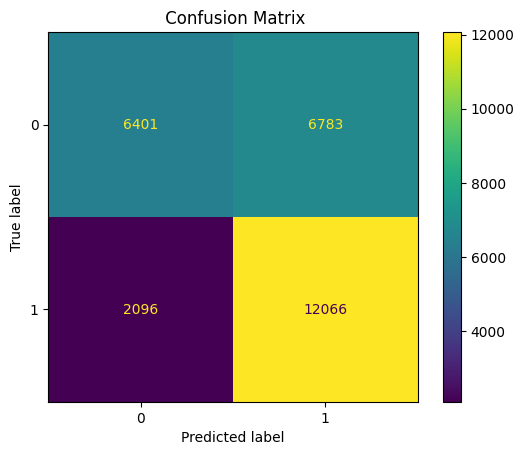

AUC: 0.667


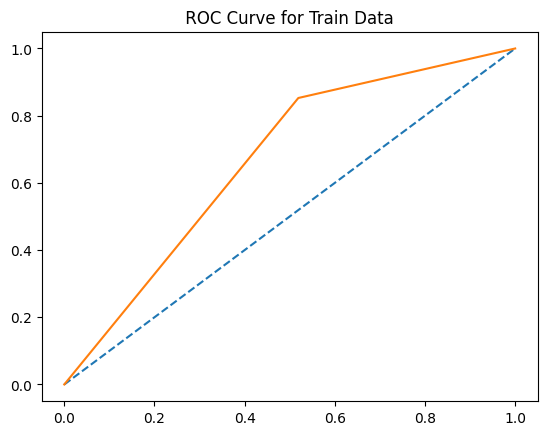

AUC: 0.669


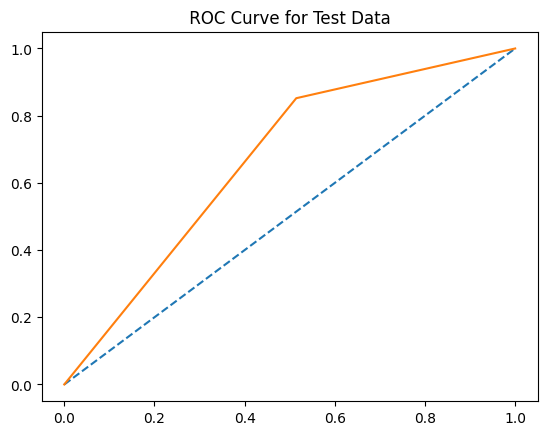

In [79]:
rfc=RandomForestClassifier(**study.best_params)
model_analyze(rfc)
pred_Y = rfc.predict(test_X)
kf = KFold(n_splits=5, random_state=None)
result = cross_val_score(rfc, val_X, val_Y, cv=kf)
cross_acc.append(result.mean())
auc.append(roc_auc_score(test_Y, pred_Y))

Hyper Parameter Tuning for KNN

In [80]:
def knn_objective(trial):
    n_neighbors = trial.suggest_int("n_neighbors", 1, 50)
    weights = trial.suggest_categorical("weights", ['uniform', 'distance'])
    metric = trial.suggest_categorical("metric", ['euclidean', 'manhattan', 'minkowski'])
    model = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights, metric=metric)
    model.fit(train_X,train_Y)
    pred_Y = model.predict(test_X)
    model.fit(train_X,train_Y)
    pred_Y = model.predict(test_X)
    kf = KFold(n_splits=5, random_state=None)
    result = cross_val_score(model, val_X, val_Y, cv=kf, scoring='f1')
    print(result.mean())
    mae = mean_absolute_error(test_Y, pred_Y)
    # Return MAE
    return mae

In [81]:
study = optuna.create_study(direction="minimize")
study.optimize(knn_objective, n_trials=200, show_progress_bar=True)
print("Best trial:", study.best_trial)
print("Best hyperparameters:", study.best_params)

[I 2024-07-28 12:18:47,427] A new study created in memory with name: no-name-9f47d395-58e4-4389-8ffe-519b47048027


  0%|          | 0/200 [00:00<?, ?it/s]

0.6995753209838125
[I 2024-07-28 12:18:51,206] Trial 0 finished with value: 0.3407445330212828 and parameters: {'n_neighbors': 17, 'weights': 'uniform', 'metric': 'euclidean'}. Best is trial 0 with value: 0.3407445330212828.
0.7050567091004506
[I 2024-07-28 12:18:53,204] Trial 1 finished with value: 0.32937175455276824 and parameters: {'n_neighbors': 37, 'weights': 'distance', 'metric': 'euclidean'}. Best is trial 1 with value: 0.32937175455276824.
0.6503110518633644
[I 2024-07-28 12:18:54,726] Trial 2 finished with value: 0.3957800043882103 and parameters: {'n_neighbors': 3, 'weights': 'distance', 'metric': 'minkowski'}. Best is trial 1 with value: 0.32937175455276824.
0.7014200059090233
[I 2024-07-28 12:18:56,723] Trial 3 finished with value: 0.33207781759672345 and parameters: {'n_neighbors': 38, 'weights': 'distance', 'metric': 'euclidean'}. Best is trial 1 with value: 0.32937175455276824.
0.6968963803503032
[I 2024-07-28 12:19:00,594] Trial 4 finished with value: 0.339428069918818

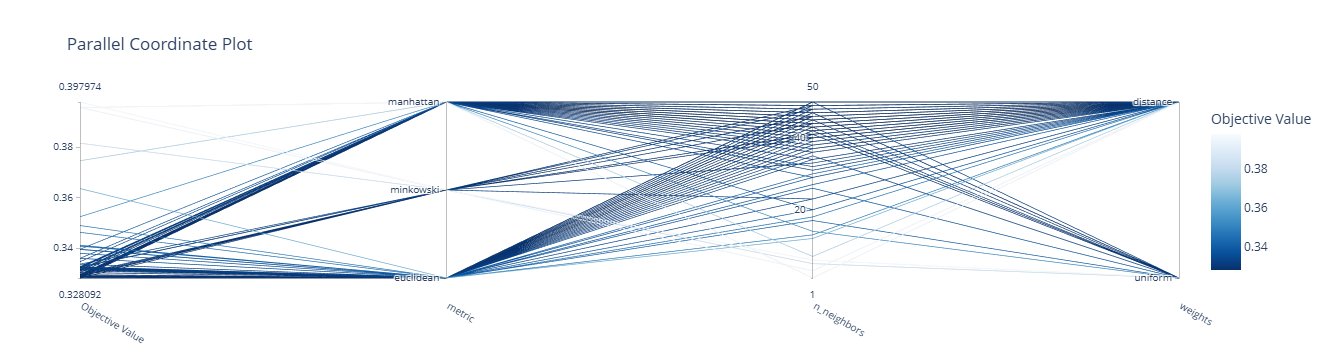

In [82]:
optuna.visualization.plot_parallel_coordinate(study)


--------------------Training Set--------------------

              precision    recall  f1-score   support

           0       0.73      0.50      0.60     61522
           1       0.64      0.83      0.72     66087

    accuracy                           0.67    127609
   macro avg       0.68      0.66      0.66    127609
weighted avg       0.68      0.67      0.66    127609


----------------------Test Set----------------------

              precision    recall  f1-score   support

           0       0.73      0.51      0.60     13184
           1       0.64      0.83      0.72     14162

    accuracy                           0.67     27346
   macro avg       0.69      0.67      0.66     27346
weighted avg       0.69      0.67      0.66     27346



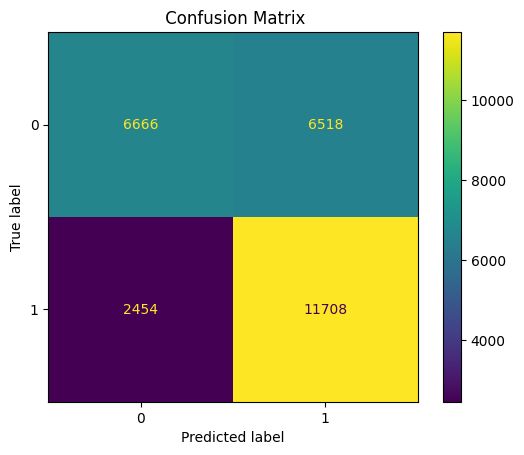

AUC: 0.664


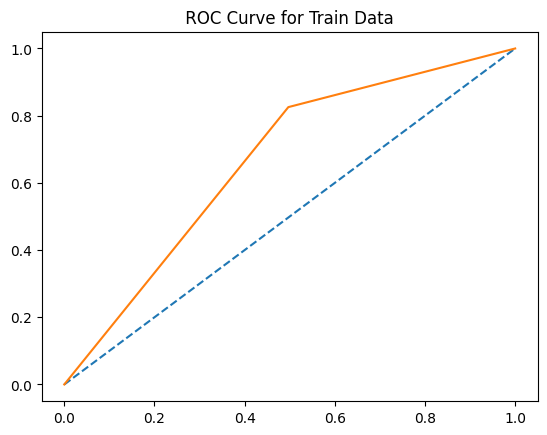

AUC: 0.666


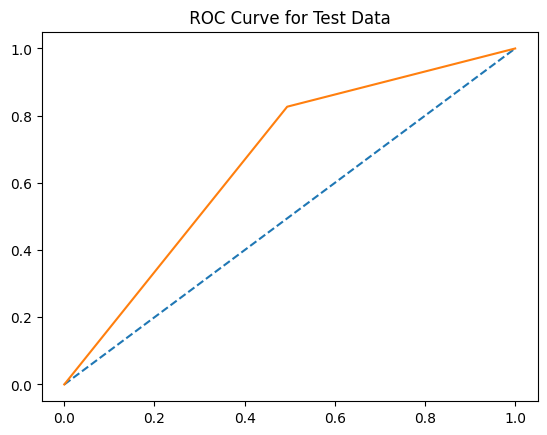

In [83]:
knn=KNeighborsClassifier(**study.best_params)
model_analyze(knn)
pred_Y = knn.predict(test_X)
result = cross_val_score(rfc, val_X, val_Y, cv=kf)
cross_acc.append(result.mean())
auc.append(roc_auc_score(test_Y, pred_Y))

Hyper Parameter Tuning for Logistic Regression

In [84]:
def log_objective(trial):
    tol= trial.suggest_float('tol' , 1e-6 , 1e-3)
    C = trial.suggest_float("C", 1e-2, 1)
    fit_intercept = trial.suggest_categorical('fit_intercept' , [True, False])
    random_state = trial.suggest_categorical('random_state' , [0, 42, 2021, 555])
    solver = trial.suggest_categorical('solver' , ['lbfgs','liblinear'])
    model = LogisticRegression(tol=tol, C=C, fit_intercept = fit_intercept, random_state=random_state, solver=solver)
    model.fit(train_X,train_Y)
    pred_Y = model.predict(test_X)
    model.fit(train_X,train_Y)
    pred_Y = model.predict(test_X)
    kf = KFold(n_splits=5, random_state=None)
    result = cross_val_score(model, val_X, val_Y, cv=kf, scoring='f1')
    print(result.mean())
    mae = mean_absolute_error(test_Y, pred_Y)
    # Return MAE
    return mae

In [85]:
study = optuna.create_study(direction="maximize")
study.optimize(log_objective, n_trials=200, show_progress_bar=True)
print("Best trial:", study.best_trial)
print("Best hyperparameters:", study.best_params)

[I 2024-07-28 12:26:14,290] A new study created in memory with name: no-name-188e5256-ce78-4af8-bd50-8401ba9f88f9


  0%|          | 0/200 [00:00<?, ?it/s]

0.6529522811310123
[I 2024-07-28 12:26:14,475] Trial 0 finished with value: 0.37998244715863383 and parameters: {'tol': 0.0006509486295184377, 'C': 0.04306705826694068, 'fit_intercept': True, 'random_state': 0, 'solver': 'liblinear'}. Best is trial 0 with value: 0.37998244715863383.
0.6422522753785118
[I 2024-07-28 12:26:14,588] Trial 1 finished with value: 0.381518320778176 and parameters: {'tol': 0.00045193809809444916, 'C': 0.7417401114500699, 'fit_intercept': False, 'random_state': 2021, 'solver': 'lbfgs'}. Best is trial 1 with value: 0.381518320778176.
0.6529042114073073
[I 2024-07-28 12:26:14,757] Trial 2 finished with value: 0.37998244715863383 and parameters: {'tol': 0.0008989915284096473, 'C': 0.7848133765730971, 'fit_intercept': True, 'random_state': 555, 'solver': 'liblinear'}. Best is trial 1 with value: 0.381518320778176.
0.6529042114073073
[I 2024-07-28 12:26:14,923] Trial 3 finished with value: 0.37998244715863383 and parameters: {'tol': 0.0007039645486286935, 'C': 0.387

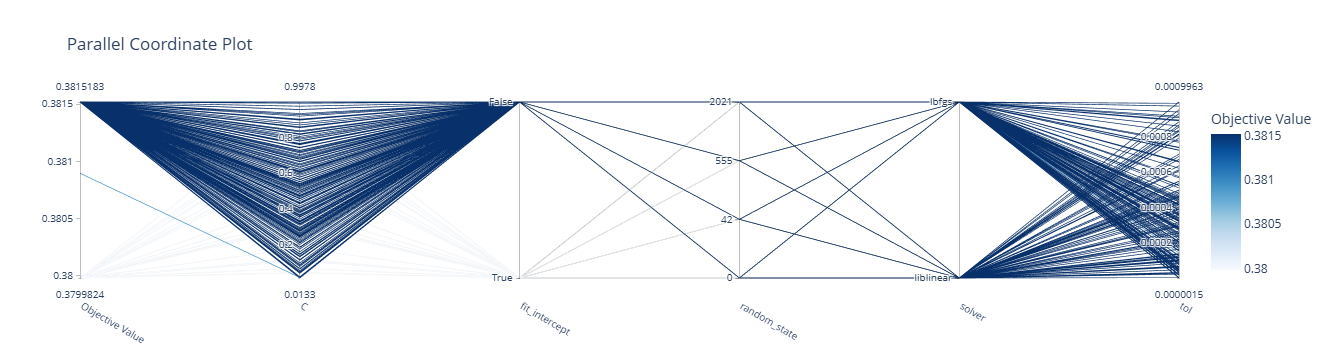

In [86]:
optuna.visualization.plot_parallel_coordinate(study)


--------------------Training Set--------------------

              precision    recall  f1-score   support

           0       0.61      0.56      0.58     61522
           1       0.62      0.66      0.64     66087

    accuracy                           0.61    127609
   macro avg       0.61      0.61      0.61    127609
weighted avg       0.61      0.61      0.61    127609


----------------------Test Set----------------------

              precision    recall  f1-score   support

           0       0.61      0.56      0.59     13184
           1       0.62      0.67      0.65     14162

    accuracy                           0.62     27346
   macro avg       0.62      0.62      0.62     27346
weighted avg       0.62      0.62      0.62     27346



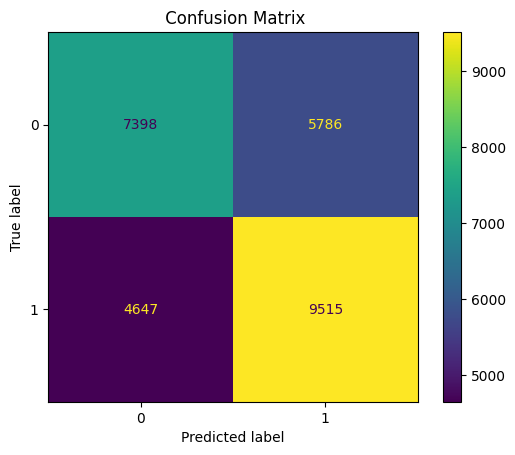

AUC: 0.612


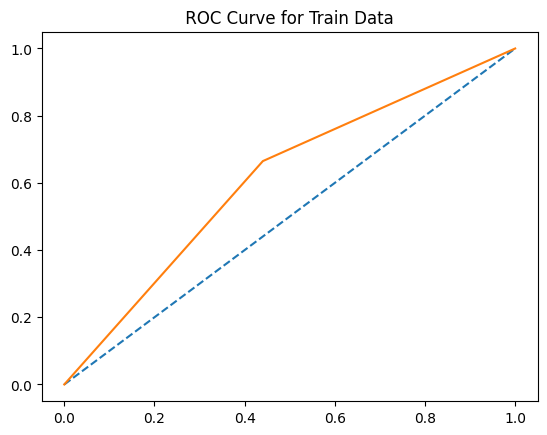

AUC: 0.617


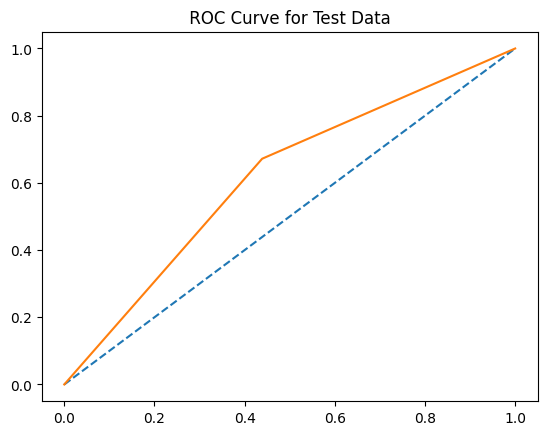

In [87]:
log=LogisticRegression(**study.best_params)
model_analyze(log)
pred_Y = log.predict(test_X)
result = cross_val_score(rfc, val_X, val_Y, cv=kf)
cross_acc.append(result.mean())
auc.append(roc_auc_score(test_Y, pred_Y))


--------------------Training Set--------------------

              precision    recall  f1-score   support

           0       0.64      0.51      0.57     61522
           1       0.62      0.74      0.67     66087

    accuracy                           0.63    127609
   macro avg       0.63      0.62      0.62    127609
weighted avg       0.63      0.63      0.62    127609


----------------------Test Set----------------------

              precision    recall  f1-score   support

           0       0.65      0.51      0.57     13184
           1       0.62      0.75      0.68     14162

    accuracy                           0.63     27346
   macro avg       0.64      0.63      0.62     27346
weighted avg       0.64      0.63      0.63     27346



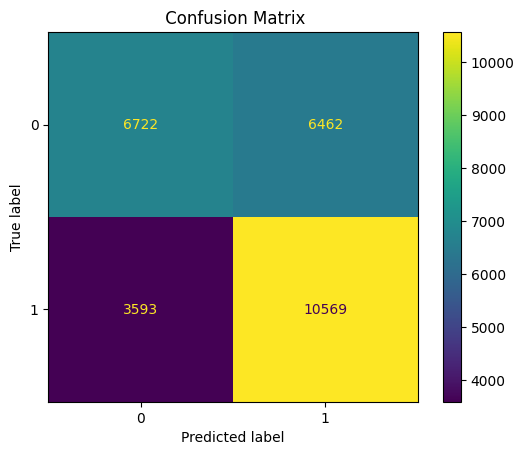

AUC: 0.623


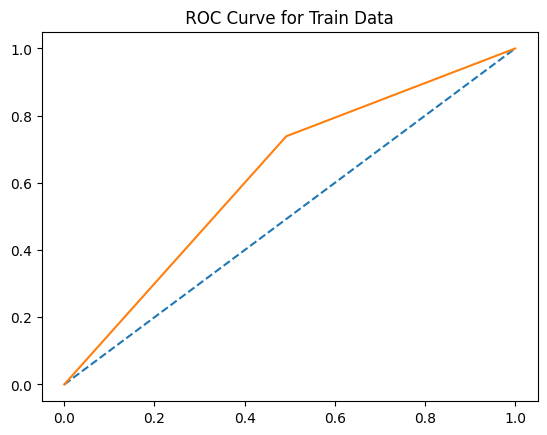

AUC: 0.628


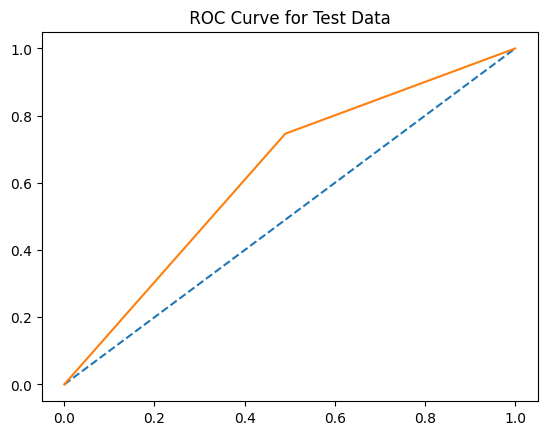

In [88]:
nb=GaussianNB()
model_analyze(nb)
pred_Y = nb.predict(test_X)
result = cross_val_score(rfc, val_X, val_Y, cv=kf)
cross_acc.append(result.mean())
auc.append(roc_auc_score(test_Y, pred_Y))

In [89]:
auc

[0.6687555240212767, 0.6661661269971741, 0.616501544455078, 0.6280766666883757]

In [90]:
cross_acc

[0.6656061437191442,
 0.6657158529895776,
 0.6655695739623331,
 0.6655330042055221]

In [91]:
max_auc=max(auc)
high_auc=auc.index(max_auc)

In [92]:
auc.index(max_auc)

0

In [93]:
if high_auc==0:
  pickle.dump(rfc, open('model.pkl','wb'))
elif high_auc==1:
  pickle.dump(knn, open('model.pkl','wb'))
elif high_auc==2:
  pickle.dump(log, open('model.pkl','wb'))
elif high_auc==3:
  pickle.dump(nb, open('model.pkl','wb'))

In [94]:
pickle.dump(encoder, open('encoder.obj','wb'))
pickle.dump(scaler, open('scaler.obj','wb'))